# Bibliotecas

In [290]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [291]:
pd.set_option('display.max_columns', None)


# 1. Importação dos dados

In [292]:
data1 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 1\dataset.json")
data1['source'] = 'dataset1'

data2 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 3\dataset.json")
data2['source'] = 'dataset2'

data3 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 5\dataset.json")
data3['source'] = 'dataset3'

data4 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 6\dataset.json")
data4['source'] = 'dataset4'

data5 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 7\dataset.json")
data5['source'] = 'dataset5'

data6 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 8\dataset.json")
data6['source'] = 'dataset6'

data7 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 9\dataset.json")
data7['source'] = 'dataset7'

data8 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 11\dataset.json")
data8['source'] = 'dataset8'

data9 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 15\dataset.json")
data9['source'] = 'dataset9'

data10 = pd.read_json(r"C:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\OneDrive_1_04-05-2026\Grupo 16\dataset.json")
data10['source'] = 'dataset10'

In [293]:
df = pd.concat([data1, data2, data3, data4, data5, data6, data7, data8, data9, data10], ignore_index = True) # Base de dados completa (todos os dados numa só).
df.head() # Algum contexto relativamente à base de dados completa.

,ElementID,SECClass_Code_EF,SECClass_Title_EF,SECClasS_Code_Ss,SECClasS_Title_Ss,SECClass_Code_Pr,SECClass_Title_Pr,Family and Type,Category,Volume,Area,Volume_to_Surface_Area_Ratio,load_bearing_status,Length,Height,Thickness/Width,Aspect_Ratio,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Phase_Created,Start_X,Start_Y,Start_Z,End_X,End_Y,End_Z,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,Comments,Keynote,Description,Materials,source
0,340318,None,None,None,None,None,None,Curtain Wall - Vão Vidro,Walls,0.0,800.279655,0.0,Non Load-Bearing,16.40200000006494,49.399999999999935,None,None,4004.678275775367,0.0,Nível 0,Unconnected,None,None,None,3.799999999999803,None,0.0,0,None,-26.693652314815985,7.880410716952276,0.0,-10.291652314751042,7.880410716952222,0.0,16.402,49.4,1.000000,-18.593652273559517,7.86791067387512,28.4999996360774,3.2350011788447236e-15,0,None,None,None,[],dataset1
1,343710,None,None,None,None,None,None,Basic Wall - Parede Betão,Walls,227.90927620402445,564.132557,0.017946363331831604,Non Load-Bearing,10.200000000103499,53.199999999999704,0.4039999999999999,131.68316831683097,1179.8187240323482,44.92995840012601,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,6,None,-10.291652314751042,7.680410716955303,0.0,-0.09165231464754382,7.6804107169552704,0.0,10.604,53.2,0.404000,-5.191652406942844,7.680410847473145,26.599999621582032,3.184903321433544e-15,0,None,None,None,['Material pré-definido de parede'],dataset1
2,344054,None,None,None,None,None,None,Basic Wall - Parede Betão,Walls,192.56175836425376,476.638595,0.016159848653996875,Non Load-Bearing,10.200000000103499,53.2,0.4039999999999999,131.6831683168317,1107.0379073686172,219.38433640196314,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,168,None,-0.09165231464755312,1.8844037552735884,0.0,-10.291652314751051,1.884403755273617,0.0,10.604,53.2,0.404000,-5.1964493395981695,1.8844037281036383,26.642322270829926,3.1415926535897905,0,None,None,None,['Material pré-definido de parede'],dataset1
3,344363,None,None,None,None,None,None,Basic Wall - Parede Betão,Walls,115.88913654394058,286.854647,0.017335835207846335,Non Load-Bearing,5.7960069616816865,53.2,0.4039999999999999,131.6831683168317,621.0516149500967,71.06595728768231,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,6,None,-6.891652314763693,7.680410716955292,0.0,-6.891652314763701,1.8844037552736057,0.0,0.404,53.2,5.796007,-6.891652306365967,4.782407360458374,26.599999621582032,1.5707963267948981,0,None,None,None,['Material pré-definido de parede'],dataset1
4,344791,None,None,None,None,None,None,Basic Wall - Parede Betão,Walls,203.769507923206,504.380583,0.016758816409414665,Non Load-Bearing,10.200000000103499,53.2,0.4039999999999999,131.6831683168317,1129.602361653343,163.33012800012622,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,116,None,-10.291652314751062,-4.521589283184926,0.0,-0.09165231464756332,-4.521589283184958,0.0,10.604,53.2,0.404000,-5.238583529921554,-4.521589268875123,26.698681729754032,3.184903321433544e-15,0,None,None,None,['Material pré-definido de parede'],dataset1


In [294]:
df.columns

Index(['ElementID', 'SECClass_Code_EF', 'SECClass_Title_EF',
       'SECClasS_Code_Ss', 'SECClasS_Title_Ss', 'SECClass_Code_Pr',
       'SECClass_Title_Pr', 'Family and Type', 'Category', 'Volume', 'Area',
       'Volume_to_Surface_Area_Ratio', 'load_bearing_status', 'Length',
       'Height', 'Thickness/Width', 'Aspect_Ratio', 'Total_Surface_Area',
       'Total_Edge_Length', 'Base_constraint', 'Top_constraint',
       'Base_extension_distance', 'Level', 'Base_level', 'Base_offset',
       'Top_level', 'Top_offset', 'Number_of_Faces', 'Phase_Created',
       'Start_X', 'Start_Y', 'Start_Z', 'End_X', 'End_Y', 'End_Z',
       'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth',
       'Centroid_X', 'Centroid_Y', 'Centroid_Z', 'Orientation_Angle',
       'Curvature', 'Comments', 'Keynote', 'Description', 'Materials',
       'source'],
      dtype='str')

In [295]:
df1 = df.copy()

# 2. Tratamento das Variáveis

In [296]:
df1 = df1.drop([
       'SECClass_Code_EF', 'SECClass_Title_EF', 
       'SECClasS_Title_Ss', 
       'SECClass_Code_Pr', 'SECClass_Title_Pr', 'Family and Type',

       'Start_X', 'Start_Y', 'Start_Z', 
       'End_X', 'End_Y', 'End_Z', 

       'Aspect_Ratio', 'Volume_to_Surface_Area_Ratio', 

       'Phase_Created', 'Comments', 'Keynote', 'Description', 'Materials'], axis=1)

df1.head()

,ElementID,SECClasS_Code_Ss,Category,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source
0,340318,None,Walls,0.0,800.279655,Non Load-Bearing,16.40200000006494,49.399999999999935,None,4004.678275775367,0.0,Nível 0,Unconnected,None,None,None,3.799999999999803,None,0.0,0,16.402,49.4,1.000000,-18.593652273559517,7.86791067387512,28.4999996360774,3.2350011788447236e-15,0,dataset1
1,343710,None,Walls,227.90927620402445,564.132557,Non Load-Bearing,10.200000000103499,53.199999999999704,0.4039999999999999,1179.8187240323482,44.92995840012601,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,6,10.604,53.2,0.404000,-5.191652406942844,7.680410847473145,26.599999621582032,3.184903321433544e-15,0,dataset1
2,344054,None,Walls,192.56175836425376,476.638595,Non Load-Bearing,10.200000000103499,53.2,0.4039999999999999,1107.0379073686172,219.38433640196314,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,168,10.604,53.2,0.404000,-5.1964493395981695,1.8844037281036383,26.642322270829926,3.1415926535897905,0,dataset1
3,344363,None,Walls,115.88913654394058,286.854647,Non Load-Bearing,5.7960069616816865,53.2,0.4039999999999999,621.0516149500967,71.06595728768231,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,6,0.404,53.2,5.796007,-6.891652306365967,4.782407360458374,26.599999621582032,1.5707963267948981,0,dataset1
4,344791,None,Walls,203.769507923206,504.380583,Non Load-Bearing,10.200000000103499,53.2,0.4039999999999999,1129.602361653343,163.33012800012622,Nível 0,Unconnected,0.0,None,None,0.0,None,0.0,116,10.604,53.2,0.404000,-5.238583529921554,-4.521589268875123,26.698681729754032,3.184903321433544e-15,0,dataset1


In [297]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 14226 entries, 0 to 14225
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ElementID                14226 non-null  int64  
 1   SECClasS_Code_Ss         14226 non-null  str    
 2   Category                 14226 non-null  str    
 3   Volume                   14226 non-null  object 
 4   Area                     14226 non-null  float64
 5   load_bearing_status      14226 non-null  str    
 6   Length                   14226 non-null  str    
 7   Height                   14226 non-null  object 
 8   Thickness/Width          14226 non-null  object 
 9   Total_Surface_Area       14226 non-null  str    
 10  Total_Edge_Length        14226 non-null  str    
 11  Base_constraint          14226 non-null  str    
 12  Top_constraint           14226 non-null  str    
 13  Base_extension_distance  14226 non-null  str    
 14  Level                    14226 no

## 2.1 Element_ID

In [298]:
df1['ElementID'].value_counts()

ElementID
344054    3
502960    3
447425    3
340318    2
343710    2
         ..
767620    1
767632    1
767644    1
767656    1
767664    1
Name: count, Length: 13622, dtype: int64

In [299]:
df1['ElementID'] = df1['ElementID'].astype('category')
df1['ElementID'].describe()

count      14226
unique     13622
top       344054
freq           3
Name: ElementID, dtype: int64

## 2.2 SECClasS_Code_Ss

### 2.2.1 Valores iniciais

In [300]:
df1['SECClasS_Code_Ss'].value_counts()

SECClasS_Code_Ss
None    14226
Name: count, dtype: int64

In [301]:
df1['SECClasS_Code_Ss'].describe()

count     14226
unique        1
top        None
freq      14226
Name: SECClasS_Code_Ss, dtype: object

### 2.2.2 Eliminar valores nulos

In [302]:
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].replace('None', np.nan)
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].replace('', np.nan)
df1['SECClasS_Code_Ss'].isnull().mean() * 100

np.float64(100.0)

In [303]:
df1 = df1.dropna(subset=['SECClasS_Code_Ss'])
df1['SECClasS_Code_Ss'].isnull().mean() * 100

nan

### 2.2.3 Eliminar após 14º dígito

In [304]:
# Remover o que vem após o 5 dígito
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].str.slice(0, 14)

# Extraindo os dígitos até o primeiro ponto
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].str.split('.').str[0]

# Mostrar o resultado
df1['SECClasS_Code_Ss'].value_counts()

Series([], Name: count, dtype: int64)

### 2.2.4 Analisar frequência de cada classe

In [305]:
freq = df1['SECClasS_Code_Ss'].value_counts()
n_min = 30
rare_classes = freq[freq < n_min].index
df1['is_rare_class'] = df1['SECClasS_Code_Ss'].isin(rare_classes).astype(int)
df1['is_rare_class'].value_counts()

Series([], Name: count, dtype: int64)

In [306]:
# Remover linhas raras (como combinámos)
df1 = df1[df1["is_rare_class"] != 1].copy()

### 2.2.5 Separar por níveis

In [307]:
df1['SECClasS_Code_Ss_1'] = df1['SECClasS_Code_Ss']
df1['SECClasS_Code_Ss_2'] = df1['SECClasS_Code_Ss']

df1.head()

,ElementID,SECClasS_Code_Ss,Category,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2


#### 2.2.5.1 Nível 1 + Encoder

In [308]:
# Remover o que vem após o 5 dígito
df1['SECClasS_Code_Ss_1'] = df1['SECClasS_Code_Ss_1'].str.slice(0, 5)

# Mostrar o resultado
print("Distribuição:")
print(df1['SECClasS_Code_Ss_1'].value_counts())

Distribuição:
Series([], Name: count, dtype: int64)


In [309]:
# Criando o objeto LabelEncoder
encoder1 = LabelEncoder()

# Aplicando o LabelEncoder na coluna 'SECClasS_Code_Ss'
df1['SECClasS_Code_Ss_1_encode'] = encoder1.fit_transform(df1['SECClasS_Code_Ss_1'])

# Exibir a relação entre os valores originais e os valores codificados
for original1, encoded1 in zip(encoder1.classes_, range(len(encoder1.classes_))):
    print(f"'{original1}' foi codificado como {encoded1}")

#### 2.2.5.2 Nível 2 + Encoder

In [310]:
# Remover o que vem após o 5 dígito
df1['SECClasS_Code_Ss_2'] = df1['SECClasS_Code_Ss_2'].str.slice(0, 8)

# Mostrar o resultado
print("Distribuição:")
print(df1['SECClasS_Code_Ss_2'].value_counts())

Distribuição:
Series([], Name: count, dtype: int64)


In [311]:
# Criando o objeto LabelEncoder
encoder2 = LabelEncoder()

# Aplicando o LabelEncoder na coluna 'SECClasS_Code_Ss'
df1['SECClasS_Code_Ss_2_encode'] = encoder2.fit_transform(df1['SECClasS_Code_Ss_2'])

# Exibir a relação entre os valores originais e os valores codificados
for original2, encoded2 in zip(encoder2.classes_, range(len(encoder2.classes_))):
    print(f"'{original2}' foi codificado como {encoded2}")

## 2.3 Category

In [312]:
df1['Category'].value_counts()

Series([], Name: count, dtype: int64)

### 2.3.1 Dummies

In [313]:
# Guardar uma cópia
df1['Category_original'] = df1['Category']

df1['Category'] = df1['Category'].astype('category')

# Realize o one-hot encoding
df1 = pd.get_dummies(df1, columns=['Category'])#, drop_first=True)

df1.head

<bound method NDFrame.head of Empty DataFrame
Columns: [ElementID, SECClasS_Code_Ss, Volume, Area, load_bearing_status, Length, Height, Thickness/Width, Total_Surface_Area, Total_Edge_Length, Base_constraint, Top_constraint, Base_extension_distance, Level, Base_level, Base_offset, Top_level, Top_offset, Number_of_Faces, Bounding_Box_Width, Bounding_Box_Height, Bounding_Box_Depth, Centroid_X, Centroid_Y, Centroid_Z, Orientation_Angle, Curvature, source, is_rare_class, SECClasS_Code_Ss_1, SECClasS_Code_Ss_2, SECClasS_Code_Ss_1_encode, SECClasS_Code_Ss_2_encode, Category_original]
Index: []>

In [314]:
df1['Category_Doors'] = df1['Category_Doors'].astype(int)
df1['Category_Floors'] = df1['Category_Floors'].astype(int)
df1['Category_Roofs'] = df1['Category_Roofs'].astype(int)
df1['Category_Stairs'] = df1['Category_Stairs'].astype(int)
df1['Category_Structural Columns'] = df1['Category_Structural Columns'].astype(int)
df1['Category_Structural Foundations'] = df1['Category_Structural Foundations'].astype(int)
df1['Category_Structural Framing'] = df1['Category_Structural Framing'].astype(int)
df1['Category_Walls'] = df1['Category_Walls'].astype(int)
df1['Category_Windows'] = df1['Category_Windows'].astype(int)
df1['Category_Curtain Panels'] = df1['Category_Curtain Panels'].astype(int)

df1.head()

KeyError: 'Category_Doors'

## 2.4 Volume

### 2.4.1 Análise de valores

In [ ]:
df1['Volume'] = df1['Volume'].astype('float')
df1['Volume'].value_counts()

Volume
0.083600    335
0.000000    217
0.323629    105
0.065835     89
0.085037     81
           ... 
0.238500      1
3.372677      1
0.358109      1
0.684859      1
0.106181      1
Name: count, Length: 7381, dtype: int64

In [ ]:
df1['Volume'].describe()

count    12350.000000
mean         2.767656
std         19.258321
min          0.000000
25%          0.083600
50%          0.274001
75%          1.119146
max        835.728535
Name: Volume, dtype: float64

### 2.4.2 Estudo de outliers

<Axes: xlabel='Volume'>

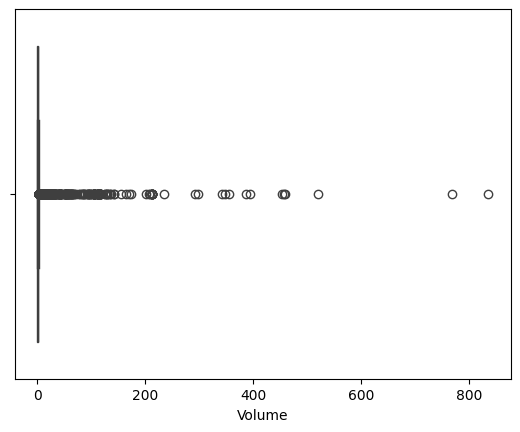

In [ ]:
sns.boxplot(x=df1['Volume'])

In [ ]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Volume', ascending=False).head(1000)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
11575,1470420,Ss_30_12,835.728535,879.715316,Non Load-Bearing,1.630000,None,0.9500000000000001,1973.5639126910219,144.35544447108205,None,None,None,Piso 0,None,None,None,None,27,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11576,1681803,Ss_30_12,768.503190,2195.726067,Non Load-Bearing,1.630000,None,0.35000000000000003,4491.060354742574,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.733482,1484.807282,Load-Bearing,4.167618,None,0.35000000000000003,3064.442662287986,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11562,352433,Ss_30_12,459.220477,1093.383416,Non Load-Bearing,1.630000,None,0.42000000000000004,2340.000978599958,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11583,2717318,Ss_30_12,456.337178,1086.518412,Non Load-Bearing,1.630000,None,0.42000000000000004,2328.725163439616,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6030,4546750,Ss_20_30_75_15,4.511993,15.519993,None,2.050000,None,None,31.03998663552873,13.411199999999964,None,None,None,PISO -3,PISO -3,0.0,PISO 0_L02,-0.2,6,0.6000000000000022,9.399999999999977,1.3999999999999937,-111.98489014892579,60.7739253112793,78.50000147094727,None,None,dataset2,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
5964,2599778,Ss_20_30_75_15,4.511993,15.519993,None,2.050000,None,None,31.03998663552873,13.411199999999974,None,None,None,PISO -3,PISO -3,0.0,PISO 0_L02,-0.2,6,0.6000000000000022,9.399999999999977,1.3999999999999937,-103.4080043701172,54.07392496948243,78.50000147094727,None,None,dataset2,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
5958,2497027,Ss_20_30_75_15,4.511993,15.519993,None,2.050000,None,None,31.03998663552873,13.411199999999974,None,None,None,PISO -3,PISO -3,0.0,PISO 0_L02,-0.2,6,0.6000000000000022,9.399999999999977,1.4000000000000024,-128.03678012695312,64.02292467041016,78.50000147094727,None,None,dataset2,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
5965,2599780,Ss_20_30_75_15,4.511993,15.519993,None,2.050000,None,None,31.03998663552873,13.411199999999974,None,None,None,PISO -3,PISO -3,0.0,PISO 0_L02,-0.2,6,0.6000000000000022,9.399999999999977,1.3999999999999937,-103.4080043701172,60.7739253112793,78.50000147094727,None,None,dataset2,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0


Os outliers não foram removidos, pois os modelos utilizados não são sensíveis às escalas dos dados.

### 2.4.3 Analisar valores = 0

In [ ]:
df1[df1['Volume'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
1317,1406020,Ss_20_20_75_15,0.0,0.000000,None,27.698000,None,None,None,None,None,None,None,,None,None,None,None,None,27.698643,1.39,0.25,None,None,None,2.502111931370395e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
3879,5039663,Ss_25_10_20,0.0,5.455998,Non Load-Bearing,1.600000,3.4099999999999873,None,27.530488146566796,0.0,PISO 0_L02,Up to level: PISO 1,None,None,None,0.0,None,-0.28999999999999687,0,1.7750000000000123,3.4099999999999873,0.9999999999999979,-87.64327360840755,68.28642451895688,85.10500063476084,3.141592653589793,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
3964,5148305,Ss_25_10_20,0.0,6.319997,Non Load-Bearing,1.600000,3.9499999999999855,None,31.877486274937734,0.0,PISO 0_L02,Up to level: PISO 1,None,None,None,-0.5399999999999985,None,-0.28999999999999687,0,1.6,3.9499999999999855,0.9999999999999979,-119.75989464109765,68.273925659174,84.83500316159724,3.141592653589793,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
5702,8985376,Ss_25_10_20,0.0,7.135997,Non Load-Bearing,1.600000,4.459999999999991,None,35.982984507288414,0.0,PISO 0_L01-A,Up to level: PISO 1,None,None,None,0.21092033729577508,None,-0.28999999999999687,0,1.6,4.459999999999991,1.0000000000000067,-133.14816115722536,68.26642543482599,84.58000012206865,3.141592653589788,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
5997,3875390,Ss_20_30_75_15,0.0,0.000000,None,2.050000,None,None,None,None,None,None,None,PISO 9,PISO 9,0.0,PISO 9,-0.24999999999999997,None,1.3999999999999937,0.24999999999999514,0.500000000000025,None,None,None,None,None,dataset2,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12594,4948569,Ss_25_30_20_30,0.0,4.219998,Non Load-Bearing,2.000000,2.1099999999999968,None,21.305490826780243,0.0,Piso 0,Up to level: Piso 0,None,None,None,-0.009999999999997726,None,2.099999999999996,0,2.228974,2.11,1.676397,-16.041883704335667,-5.860152484038152,44.345000207519675,2.757620218151045,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
12595,4955627,Ss_25_30_20_30,0.0,2.381624,Non Load-Bearing,1.095000,2.1749999999999994,None,12.071619802484483,0.0,Piso 0,Up to level: Piso 0,None,None,None,0.0,None,2.1750000000000034,0,1.337378,2.175,1.389873,-9.89914454886399,-6.4359699106378905,44.387499938964766,1.9547687622336476,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
12596,4955902,Ss_25_30_20_30,0.0,1.368446,Non Load-Bearing,1.091000,2.100339370020067,None,6.960106193133264,0.0,Piso 0,Up to level: Beirado 1,None,None,None,2.1750000000000034,None,0.0,0,1.33588,2.100339,1.386164,-9.92398473696752,-6.4278776322521285,46.1039398632287,1.9547687622336467,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
12601,5055020,Ss_25_30_20_30,0.0,15.949126,Non Load-Bearing,5.370000,2.1,None,80.16565199139134,0.0,Piso 0,Unconnected,None,None,None,0.0,None,-0.7880999999999999,0,2.938821,3.540897,5.353584,-21.580054161592663,-5.231103149597561,44.803327737103615,1.9547687622336472,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0


Estes valores a 0 no volume são normais, o revit não consegue extrair o volume das escadas é uma limitação do software.


### 2.4.4 Arredondar c/ 2 casas decimais

In [ ]:
df1["Volume"] = df1["Volume"].round(2)

## 2.5 Area

### 2.5.1 Análise de valores

In [ ]:
df1['Area'] = df1['Area'].astype('float')
df1['Area'].value_counts()

Area
0.000000     765
1.816499     336
3.317176     130
5.668598     105
3.092050      90
            ... 
12.590912      1
12.892371      1
12.860371      1
6.708747       1
3.746562       1
Name: count, Length: 6933, dtype: int64

In [ ]:
df1['Area'].describe()

count    12350.000000
mean        11.104284
std         58.407781
min          0.000000
25%          1.469999
50%          3.379593
75%          6.897497
max       2195.726067
Name: Area, dtype: float64

### 2.5.2 Estudo de outliers

<Axes: xlabel='Area'>

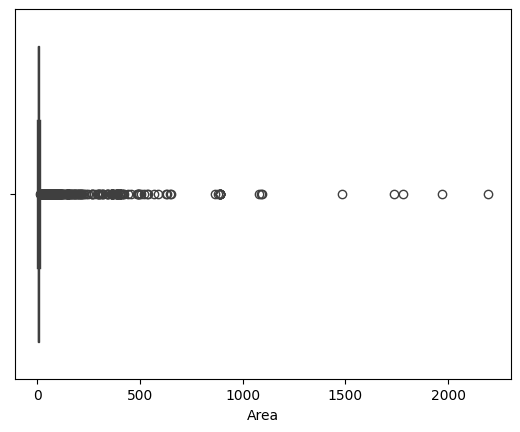

In [ ]:
sns.boxplot(x=df1['Area'])

In [ ]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Area', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
11576,1681803,Ss_30_12,768.50,2195.726067,Non Load-Bearing,1.630000,None,0.35000000000000003,4491.060354742574,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.967853,Non Load-Bearing,2.050000,None,0.2,3976.5436878719515,124.01702399998706,None,None,None,PISO -3,None,None,None,None,6,75.42999999999296,0.19999999999999785,26.089999999996433,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.037166,Non Load-Bearing,2.050000,None,0.2,3618.379322669467,181.06607692977394,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.743446,Non Load-Bearing,2.050000,None,0.2,3528.959845243135,159.0837821889595,None,None,None,PISO -2,None,None,None,None,42,75.42999999999303,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.807282,Load-Bearing,4.167618,None,0.35000000000000003,3064.442662287986,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11562,352433,Ss_30_12,459.22,1093.383416,Non Load-Bearing,1.630000,None,0.42000000000000004,2340.000978599958,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11583,2717318,Ss_30_12,456.34,1086.518412,Non Load-Bearing,1.630000,None,0.42000000000000004,2328.725163439616,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
11573,1460272,Ss_30_12,453.05,1078.701666,Non Load-Bearing,1.630000,None,0.42000000000000004,2321.985057483911,254.75270478615602,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
7700,1927730,Ss_30_12_85_18,213.24,888.491997,Load-Bearing,1.450001,None,0.23999999463558197,1826.3195017209202,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,107.18000203857423,None,None,dataset3,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
7699,1927216,Ss_30_12_85_18,213.24,888.491997,Load-Bearing,1.450001,None,0.23999999463558197,1826.3195017209202,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,104.28000230712891,None,None,dataset3,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,

### 2.5.3 Análise de valores = 0

In [ ]:
df1[df1['Area'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
977,1824674,Ss_20_30_75_80,0.01,0.0,None,2.575000,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.0,None,2.575000,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.0,None,2.575000,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.0,None,2.575000,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.0,None,2.575000,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9173,1437083,Ss_20_20_75_80,0.00,0.0,None,3.000000,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,dataset5,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
9174,1437167,Ss_20_20_75_80,0.00,0.0,None,3.000000,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,dataset5,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
9175,1437215,Ss_20_20_75_80,0.00,0.0,None,3.000000,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,dataset5,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
9176,1437249,Ss_20_20_75_80,0.00,0.0,None,3.000000,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.967055934277598e-13,0,dataset5,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0


### 2.5.4 Arredondar c/ 2 casas decimais

In [ ]:
df1["Area"] = df1["Area"].round(2)

## 2.6 load_bearing_status

### 2.6.1 Análise de valores

In [ ]:
df1['load_bearing_status'].value_counts()

load_bearing_status
Non Load-Bearing    6082
None                5816
Load-Bearing         452
Name: count, dtype: int64

### 2.6.2 Replace None

In [ ]:
# Função para aplicar a transformação de maiúsculas e substituições
def aplicar_transformacoes(col):

    # Substituições específicas
    col = col.replace("None", "Non Load-Bearing")

    return col

# Aplicar as transformações
colunas = ['load_bearing_status']
for col in colunas:
    df1[col] = aplicar_transformacoes(df1[col])

df1['load_bearing_status'].value_counts()

load_bearing_status
Non Load-Bearing    11898
Load-Bearing          452
Name: count, dtype: int64

### 2.6.3 Tornar uma variável binária

In [ ]:
df1["load_bearing_status_binary"] = (
    df1["load_bearing_status"]
    .str.strip()            # remove espaços extra
    .str.lower()            # normaliza para minúsculas
    .map({
        "non load-bearing": 0,
        "load-bearing": 1
    })
)

df1['load_bearing_status_binary'].value_counts()

load_bearing_status_binary
0    11898
1      452
Name: count, dtype: int64

## 2.7 Length

In [ ]:
colunas = ['Length', 'Height', 'Thickness/Width']

for coluna in colunas:
    # Converter para float, erros viram NaN
    df1[coluna + '_float'] = pd.to_numeric(df1[coluna], errors='coerce')
    count_zero = (df1[coluna + '_float'] == 0).sum()
    count_nan = df1[coluna + '_float'].isna().sum()
    print(f"Coluna: {coluna}")
    print(f"  0: {count_zero}")
    print(f"  NaN (inclui 'None' e não numéricos): {count_nan}\n")

Coluna: Length
  0: 0
  NaN (inclui 'None' e não numéricos): 0

Coluna: Height
  0: 26
  NaN (inclui 'None' e não numéricos): 3777

Coluna: Thickness/Width
  0: 41
  NaN (inclui 'None' e não numéricos): 3325



In [ ]:
df1.drop(columns=['Length_float', 'Height_float', 'Thickness/Width_float'], inplace=True)

### 2.7.1 Análise de valores

In [ ]:
df1['Length'].value_counts()

Length
2.050000    1893
2.575000     617
1.630000     506
1.450001     432
4.167618     350
            ... 
6.175000       1
6.275000       1
3.620000       1
5.450000       1
3.240000       1
Name: count, Length: 4318, dtype: int64

In [ ]:
df1['Length'].describe()

count    12350.000000
mean         3.397136
std          5.018239
min          0.009962
25%          1.500000
50%          2.050000
75%          3.476786
max         75.380000
Name: Length, dtype: float64

In [ ]:
df1['Length'] = df1['Length'].replace('None', np.nan)
df1['Length'].isnull().mean() * 100

0.0

In [ ]:
df1.describe()

,Volume,Area,Length,is_rare_class,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
count,12350.000000,12350.000000,12350.000000,12350.0,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000,12350.000000
mean,2.767531,11.104198,3.397136,0.0,0.813279,5.122753,0.007449,0.100405,0.030850,0.000972,0.006397,0.126235,0.012308,0.171012,0.498219,0.046154,0.036599
std,19.258353,58.407779,5.018239,0.0,0.756296,3.641675,0.085991,0.300551,0.172919,0.031158,0.079727,0.332127,0.110260,0.376535,0.500017,0.209827,0.187783
min,0.000000,0.000000,0.009962,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.080000,1.470000,1.500000,0.0,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.270000,3.380000,2.050000,0.0,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.120000,6.900000,3.476786,0.0,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,835.730000,2195.730000,75.380000,0.0,5.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 2.7.2 Estudo de outliers

<Axes: xlabel='Length'>

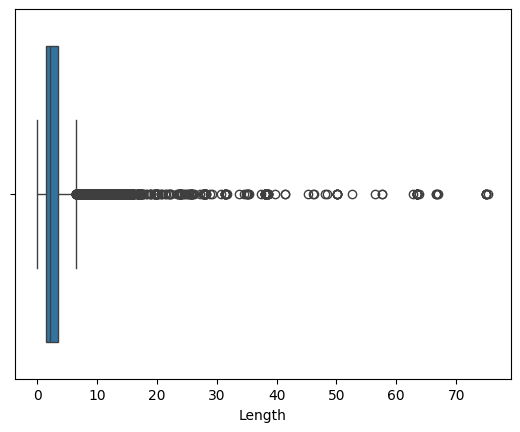

In [ ]:
sns.boxplot(x=df1['Length'])

In [ ]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Length', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2653,1543186,Ss_25_13_50,104.84,237.10,Non Load-Bearing,75.380000,2.5390796627042063,0.44999999999999996,554.4423159733082,115.88467948102405,PISO -1,Up to level: PISO 0_L01-A,0.0,None,None,0.0,None,-4.839062484052193e-15,29,75.42999999986202,3.5999999999999788,0.4500000000010326,-111.75407582492267,68.14981034171345,81.22975677212139,3.2178593388602265e-15,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2650,1542874,Ss_25_13_50,93.47,211.20,Non Load-Bearing,74.980000,2.799999999999996,0.44999999999999996,499.53478492195427,104.56773599995174,PISO -2,Up to level: PISO -1,0.0,None,None,0.0,None,-0.2,18,75.42999999999302,2.799999999999996,0.4500000000002442,-114.72356189152683,68.14976271611071,77.99999943237304,3.2350258330603172e-15,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
5378,8341071,Ss_25_13_50,95.04,211.20,Non Load-Bearing,74.980000,2.8000000000000047,0.44999999999999996,492.8147878152937,91.08033599995147,PISO -3,Up to level: PISO -2,0.0,None,None,0.0,None,6.497202775790357e-15,6,75.429999999993,2.799999999999996,0.4500000000002442,-114.39800332031251,68.14892398681641,75.20000057373048,3.2350258330603172e-15,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2649,1542866,Ss_25_13_50,101.83,226.29,Non Load-Bearing,74.980000,3.211086872436025,0.44999999999999996,523.166774747042,47.81092799999575,PISO -2,Up to level: PISO -1,0.0,None,None,-0.21108687243602278,None,0.0,8,75.429999999993,3.0110868724360187,0.4500000000002182,-114.39800332031251,42.508926232910156,77.90000088500977,3.1415926535897905,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2652,1543115,Ss_25_13_50,134.54,299.15,Non Load-Bearing,74.980000,3.989745623114483,0.44999999999999996,669.8307363029431,96.18237786365279,PISO -1,Up to level: PISO 0_L02,0.0,None,None,-0.20974562311449338,None,-0.019999999999999785,10,75.20499999999299,3.989745623114483,0.45000000000020957,-114.16478000303731,42.508905473064345,81.38412007712539,3.1415926535897905,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2646,1542586,Ss_25_13_50,88.25,196.12,Non Load-Bearing,74.980000,2.799999999999996,0.44999999999999996,462.4628008835449,47.451263999995724,PISO -3,Up to level: PISO -2,0.0,None,None,0.0,None,0.0,7,75.42999999999299,2.599999999999998,0.4500000000002182,-114.39800332031251,42.508926232910156,75.10000202636719,3.1415926535897905,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
1771,1757481,Ss_20_20_75_15,4.02,33.53,Non Load-Bearing,66.938188,None,None,67.05815862767837,81.73295820001324,None,None,None,,None,None,None,None,6,66.938188,1.19,0.2,1010.7500258789063,289.94296267089845,96.920000390625,3.1060071476428555e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1772,1757706,Ss_20_20_75_15,4.01,33.48,Non Load-Bearing,66.838188,None,None,66.95815867073726,81.51959820001719,None,None,None,,None,None,None,None,6,66.838188,1.19,0.2,1010.7000196289063,275.6648574462891,96.920000390625,3.110654202363692e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1426,1572211,Ss_20_20_75_15,26.84,110.30,Non Load-Bearing,66.713188,None,None,220.60092376886337,61.406208596409314,None,None,None,,None,None,None,None,22,66.813188,1.35,0.3,1010.77845608166

### 2.7.3 Arredondar c/ 2 casas decimais

In [ ]:
df1["Length"] = df1["Length"].round(2)

## 2.8 Height

### 2.8.1 Análise de valores

In [ ]:
df1['Height'].value_counts()

Height
None                  3777
2.1                   1110
2.660000000000002      469
2.650000000000004      400
2.6500000000000212     397
                      ... 
3.2699999999999965       1
2.8799999999999994       1
3.2199999999999958       1
0.7799999999999959       1
2.289999999999999        1
Name: count, Length: 513, dtype: int64

### 2.8.2 Replace None -> 0

In [ ]:
df1['Height'] = df1['Height'].replace('None', np.nan)
df1['Height'].isnull().mean() * 100

30.582995951417004

In [ ]:
df1['Height'] = df1['Height'].replace(np.nan , 0)
df1['Height'] = df1['Height'].astype('float')
df1['Height'].describe()

count    12350.000000
mean         1.792457
std          1.982742
min          0.000000
25%          0.000000
50%          2.100000
75%          2.660000
max         32.700000
Name: Height, dtype: float64

### 2.8.3 Análise de valores = 0

In [ ]:
df1[df1['Height'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.0,0.35000000000000003,771.9378580874436,45.39538345404171,None,None,None,3 STR - Piso 0,None,None,None,None,55,27.75,0.35,13.359996,1030.0941113995514,282.8376130075494,83.83499908447266,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.0,0.2,704.4002280199712,29.30235693153484,None,None,None,4 STR - Piso 1,None,None,None,None,20,28.0,0.2,13.359996,1030.9771866486471,282.5956018986259,86.93000086669922,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.0,0.2,718.0873473366955,74.83515598898916,None,None,None,5 STR - Piso 2,None,None,None,None,37,27.95,0.2,13.609996,1030.6749778762403,282.6414050313977,89.99000013427735,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.0,0.2,657.0169356484246,32.90897814686379,None,None,None,4 STR - Piso 1,None,None,None,None,15,23.792046,0.2,13.594996,1004.1025665236061,282.819141232684,86.93000086669922,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.0,0.2,398.20035505519235,21.13740576782895,None,None,None,5 STR - Piso 2,None,None,None,None,6,12.975,0.2,14.91501,987.464042578125,282.2580550048828,89.99000013427735,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12119,1722681,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso 0,0.0,Piso 1,0.0,None,2.997569,3.3,4.03173,None,None,None,None,None,dataset6,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
12120,3312766,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso 0,-0.05,Piso 1,1.4,None,2.01803,4.75,1.527643,None,None,None,None,None,dataset6,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
12121,3367980,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso -1,-1.35,None,0.44999999999999996,None,1.55,1.0,9.4,None,None,None,None,None,dataset6,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
12122,4174963,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso -1,-1.05,Piso -1,-0.35,None,5.25,0.8,1.8,None,None,None,None,None,dataset6,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0


### 2.8.4 Análise de outliers

<Axes: xlabel='Height'>

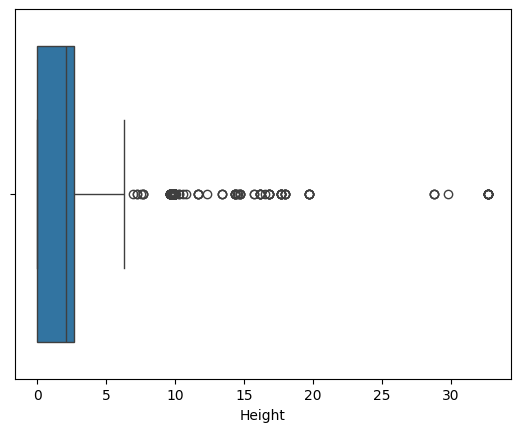

In [ ]:
sns.boxplot(x=df1['Height'])

In [ ]:
# Ordenar pelas maiores 
df1.sort_values(by='Height', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7679,1908353,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339057334,32.52215939039986,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.149999,37.15311244812012,21.81500099487305,99.34520119628907,1.570796326794941,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7677,1908349,Ss_25_11_16_70,13.41,67.04,Load-Bearing,2.05,32.70,0.2,147.97000209054397,12.466321219200099,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.150001,32.7,0.2,36.02811251220703,22.940000930786134,99.34520119628907,3.1415926535896688,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7670,1908331,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.2,149.61506718224476,12.374882438399993,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.225,32.7,0.2,12.973641242980957,22.940003256225587,99.34520119628907,2.0791048882529185e-13,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7671,1908333,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339059795,32.52215939040032,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.15,13.911142158508301,21.815003320312503,99.34520119628907,1.570796326794819,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7672,1908335,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.05,32.70,0.2,147.96993629057866,12.466320000000216,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.15,32.7,0.2,15.036142094421388,22.940003256225587,99.34520119628907,1.605812718569185e-13,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7673,1908337,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339057632,32.52215939039992,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.149999,15.961142028808595,21.815003320312503,99.34520119628907,1.5707963267949017,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7674,1908341,Ss_25_11_16_70,25.80,93.20,Load-Bearing,3.10,32.70,0.2767910000000029,206.06988328241218,11.704321219199969,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.276791,32.7,3.099997,33.61650622558594,24.265000286865234,99.34520119628907,1.5707963267948883,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7676,1908347,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.2,149.61506718222452,12.374882438399622,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.225,32.7,0.2,38.09061336364746,22.940000930786134,99.34520119628907,3.141592653589638,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7675,1908343,Ss_25_11_16_70,18.55,67.03,Load-Bearing,2.05,32.70,0.2767910000000029,153.30684253914524,22.602010574400005,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.276791,32.7,2.049999,33.61650622558594,21.814999832153323,99.34520119628907,1.5707963267948966,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7678,1908351,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339059013,32.52215939040018,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.15,35.103111996459965,21.81500099487305,99.34520119628907,1.5707963267949026,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1


### 2.8.5 Arredondar c/ 2 casas decimais

In [ ]:
df1["Height"] = df1["Height"].round(2)

## 2.9 Thickness/Width

### 2.9.1 Análise de valores

In [ ]:
df1['Thickness/Width'].value_counts()

Thickness/Width
None                   3325
0.14999999999999997    1917
0.2                     662
0.15000000000000002     477
0.01                    433
                       ... 
0.24700000000000003       1
0.42500000000000004       1
1.1225466458959423        1
15.80000066757202         1
0.9000000000000011        1
Name: count, Length: 242, dtype: int64

### 2.9.2 Replace None -> 0

In [ ]:
df1['Thickness/Width'] = df1['Thickness/Width'].replace('None', np.nan)
df1['Thickness/Width'].isnull().mean() * 100

26.923076923076923

In [ ]:
df1['Thickness/Width'] = df1['Thickness/Width'].replace(np.nan , 0)
df1['Thickness/Width'] = df1['Thickness/Width'].astype('float')
df1['Thickness/Width'].describe()

count    12350.000000
mean         0.351402
std          1.161645
min          0.000000
25%          0.000000
50%          0.150000
75%          0.300000
max         52.250000
Name: Thickness/Width, dtype: float64

### 2.9.3 Análise valores = 0

In [ ]:
df1[df1['Thickness/Width'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
268,1401380,Ss_30_12_05,6.82,36.36,Load-Bearing,4.17,0.00,0.0,83.84089683431915,27.636364813932747,None,None,None,4 STR - Piso 1,None,None,None,None,6,28.4,0.2,1.28,1101.9756389648437,265.3128021565134,86.2538880411255,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
269,1401653,Ss_30_12_05,6.60,35.22,Load-Bearing,4.17,0.00,0.0,81.55412141723022,27.58760161342354,None,None,None,5 STR - Piso 2,None,None,None,None,6,28.4,0.2,1.24,1101.9756389648437,270.75578357400855,89.58388943272706,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
412,1306690,Ss_20_30_75_15,0.48,4.24,Non Load-Bearing,4.17,0.00,0.0,8.473196351809372,11.643360000000172,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,12,0.23,9.48,0.23,1019.5941372070313,283.66054614257814,88.44966705520649,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
413,1306692,Ss_20_30_75_15,0.46,4.20,Non Load-Bearing,4.17,0.00,0.0,8.394996385478885,10.891564286612569,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,18,0.23,9.48,0.23,1023.0941282226563,283.66054614257814,88.4842830799876,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
414,1306694,Ss_20_30_75_15,0.46,4.20,Non Load-Bearing,4.17,0.00,0.0,8.394996385478887,10.891564286612569,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,18,0.23,9.48,0.23,1026.5941192382813,283.66054614257814,88.4842830799876,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12594,4948569,Ss_25_30_20_30,0.00,4.22,Non Load-Bearing,2.00,2.11,0.0,21.305490826780243,0.0,Piso 0,Up to level: Piso 0,None,None,None,-0.009999999999997726,None,2.099999999999996,0,2.228974,2.11,1.676397,-16.041883704335667,-5.860152484038152,44.345000207519675,2.757620218151045,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
12595,4955627,Ss_25_30_20_30,0.00,2.38,Non Load-Bearing,1.10,2.17,0.0,12.071619802484483,0.0,Piso 0,Up to level: Piso 0,None,None,None,0.0,None,2.1750000000000034,0,1.337378,2.175,1.389873,-9.89914454886399,-6.4359699106378905,44.387499938964766,1.9547687622336476,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
12596,4955902,Ss_25_30_20_30,0.00,1.37,Non Load-Bearing,1.09,2.10,0.0,6.960106193133264,0.0,Piso 0,Up to level: Beirado 1,None,None,None,2.1750000000000034,None,0.0,0,1.33588,2.100339,1.386164,-9.92398473696752,-6.4278776322521285,46.1039398632287,1.9547687622336467,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
12601,5055020,Ss_25_30_20_30,0.00,15.95,Non Load-Bearing,5.37,2.10,0.0,80.16565199139134,0.0,Piso 0,Unconnected,None,None,None,0.0,None,-0.7880999999999999,0,2.938821,3.540897,5.353584,-21.580054161592663,-5.231103149597561,44.803327737103615,1.9547687622336472,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.9.4 Estudo de outliers

<Axes: xlabel='Thickness/Width'>

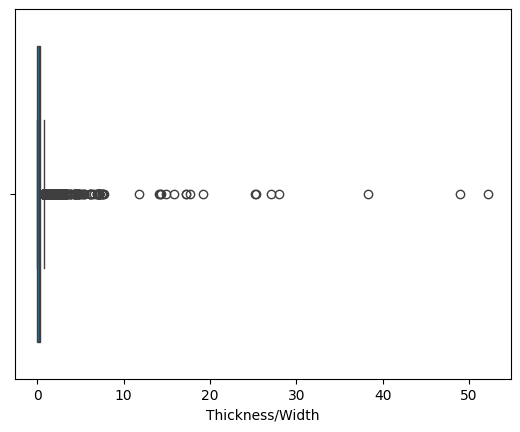

In [ ]:
sns.boxplot(x=df1['Thickness/Width'])

In [ ]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Thickness/Width', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2617,1740263,Ss_20_05_15_70,61.65,82.21,Non Load-Bearing,1.00,0.0,52.250000,245.14554633584618,62.0943485791413,None,None,None,2 STR - Piso -1,None,None,None,None,6,52.25,0.75,1.573308,1075.500641015625,296.31258317871095,80.28499716796875,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
8576,1905554,Ss_20_05_15_70,29.36,48.93,Non Load-Bearing,3.15,0.0,48.930000,157.77593542594002,60.16599639387131,None,None,None,Fund,None,None,None,None,6,48.93,0.6,1.0,24.46499970703125,0.5000000038146973,73.00000462646484,None,None,dataset3,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2616,1740195,Ss_20_05_15_70,45.93,61.24,Non Load-Bearing,1.00,0.0,38.275000,182.29242151279638,48.0212400000001,None,None,None,2 STR - Piso -1,None,None,None,None,6,38.275,0.75,1.6,1082.4881214843751,280.72923669433595,80.28499716796875,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2612,1727372,Ss_20_05_15_70,33.54,44.72,Non Load-Bearing,1.00,0.0,27.950000,133.7649424066213,36.22548000000031,None,None,None,3 STR - Piso 0,None,None,None,None,6,27.95,0.75,1.6,1029.319125,275.0155575439453,83.02499736328126,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2615,1731166,Ss_20_05_15_70,32.46,43.28,Non Load-Bearing,1.00,0.0,27.050000,129.53494422787367,33.14700000000017,None,None,None,3 STR - Piso 0,None,None,None,None,6,27.05,0.75,1.6,1029.7691440429687,290.5886069824219,83.02499736328126,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
8761,766598,Ss_20_05_15,18.51,123.39,Non Load-Bearing,11.80,0.0,25.378673,256.3977582976525,39.42702960993565,None,None,None,Level 2,None,None,None,None,10,25.37867338660245,0.15000000000000002,6.850000000000022,9.575671545580137,17.953315210914244,2.924999949645996,None,None,dataset4,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2592,1642415,Ss_20_05_15_70,16.41,32.83,Non Load-Bearing,1.00,0.0,25.251200,92.20428030083711,32.31026303999977,None,None,None,2 STR - Piso -1,None,None,None,None,6,25.2512,0.5,1.3,1071.8750390625,299.9488635498047,80.40999884033204,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2640,2227292,Ss_20_05_15_70,26.68,76.23,Non Load-Bearing,1.00,0.0,19.151500,168.65338843051697,18.877420205739114,None,None,None,2 STR - Piso -1,None,None,None,None,6,19.1515,0.35,3.980397,1049.6736779296875,301.5890611083984,80.64499844970703,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2641,2230483,Ss_20_05_15_70,7.49,14.98,Non Load-Bearing,1.00,0.0,17.625000,48.43747914492446,22.387560000000057,None,None,None,2 STR - Piso -1,None,None,None,None,6,17.625,0.5,0.85,1093.3131351562502,299.72386333007813,80.40999884033204,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2561,1606712,Ss_20_05_15_70,24.51,24.51,Non Load-Bearing,1.00,0.0,17.173046,88.17094624436328,26.088497923282638,None,None,None,3 STR - Piso 0,None,None,None,None,14,1.6,1.0,17.173046,1044.0941487304688,283.27906401242205,82.90000034179688,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0


### 2.9.5 Arredondar c/ 2 casas decimais

In [ ]:
df1["Thickness/Width"] = df1["Thickness/Width"].round(2)

## 2.10 Total_Surface_Ara

### 2.10.1 Análise de valores

In [ ]:
df1['Total_Surface_Area'].value_counts()

Total_Surface_Area
None                  2618
0.9679995832213807      68
1.9723002308131132      60
54.719976439952774      42
31.03998663552873       38
                      ... 
9.480530647139851        1
16.655092828296524       1
94.56345928509359        1
7.515240027739559        1
1.7885080853252673       1
Name: count, Length: 6904, dtype: int64

### 2.10.2 Replace None -> 0

In [ ]:
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].replace('None', np.nan)
df1['Total_Surface_Area'].describe()

count                   9732
unique                  6903
top       0.9679995832213807
freq                      68
Name: Total_Surface_Area, dtype: object

In [ ]:
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].replace(np.nan , 0)
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].astype('float')
df1['Total_Surface_Area'].describe()

count    12350.000000
mean        23.422966
std        122.008442
min          0.000000
25%          1.170056
50%          5.639891
75%         15.194443
max       4491.060355
Name: Total_Surface_Area, dtype: float64

### 2.10.3 Análise valores = 0

In [ ]:
df1[df1['Total_Surface_Area'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.10.4 Análise de outliers

<Axes: xlabel='Total_Surface_Area'>

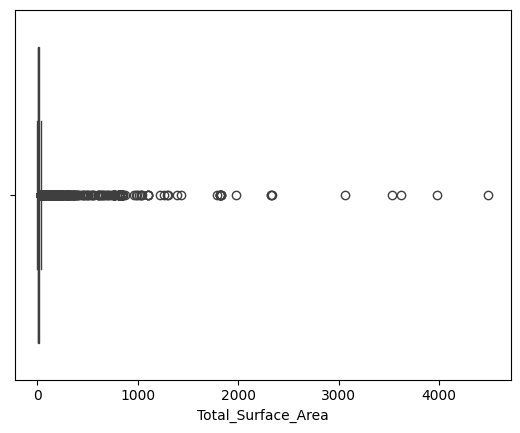

In [ ]:
sns.boxplot(x=df1['Total_Surface_Area'])

In [ ]:
# Ordenar pelas maiores
df1.sort_values(by='Total_Surface_Area', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
11576,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.0,0.35,4491.060355,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.97,Non Load-Bearing,2.05,0.0,0.20,3976.543688,124.01702399998706,None,None,None,PISO -3,None,None,None,None,6,75.42999999999296,0.19999999999999785,26.089999999996433,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.0,0.20,3618.379323,181.06607692977394,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.0,0.20,3528.959845,159.0837821889595,None,None,None,PISO -2,None,None,None,None,42,75.42999999999303,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.0,0.35,3064.442662,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
11562,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.0,0.42,2340.000979,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11583,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.0,0.42,2328.725163,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11573,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.0,0.42,2321.985057,254.75270478615602,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11575,1470420,Ss_30_12,835.73,879.72,Non Load-Bearing,1.63,0.0,0.95,1973.563913,144.35544447108205,None,None,None,Piso 0,None,None,None,None,27,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
7699,1927216,Ss_30_12_85_18,213.24,888.49,Load-Bearing,1.45,0.0,0.24,1826.319502,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,104.28000230712891,None,None,dataset3,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1


### 2.10.5 Arredondar c/ 2 casas decimais

In [ ]:
df1["Total_Surface_Area"] = df1["Total_Surface_Area"].round(2)

## 2.11 Total_Edge_Length

### 2.11.1 Análise de valores

In [ ]:
df1['Total_Edge_Length'].value_counts()

Total_Edge_Length
None                  2618
0.0                    116
13.144560959999854      60
23.77439999999997       37
1.5361919999999682      35
                      ... 
8.351406258647064        1
6.943230258647079        1
5.547303129323664        1
4.739583129323668        1
2.9267286074834815       1
Name: count, Length: 6644, dtype: int64

### 2.11.2 Replace None -> 0

In [ ]:
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].replace('None', np.nan)
df1['Total_Edge_Length'].describe()

count     9732
unique    6643
top        0.0
freq       116
Name: Total_Edge_Length, dtype: object

In [ ]:
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].replace(np.nan , 0)
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].astype('float')
df1['Total_Edge_Length'].describe()

count    12350.000000
mean         7.056781
std         13.061920
min          0.000000
25%          1.201871
50%          4.194048
75%          7.879080
max        254.752705
Name: Total_Edge_Length, dtype: float64

### 2.11.3 Análise valores = 0

In [ ]:
df1[df1['Total_Edge_Length'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.11.4 Análise de outliers

<Axes: xlabel='Total_Edge_Length'>

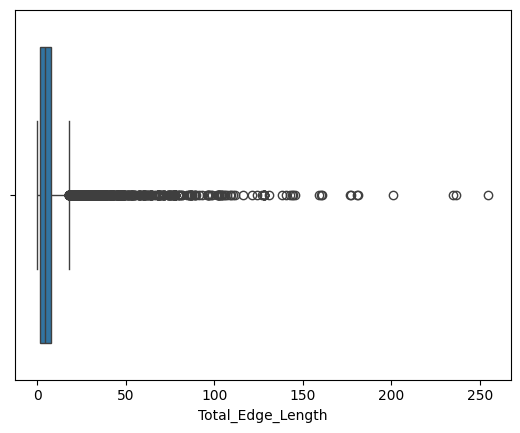

In [ ]:
sns.boxplot(x=df1['Total_Edge_Length'])

In [ ]:
# Ordenar pelas maiores
df1.sort_values(by='Total_Edge_Length', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
11573,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.0,0.42,2321.99,254.752705,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11583,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.0,0.42,2328.73,236.745283,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11562,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.0,0.42,2340.00,234.698052,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2622,1785701,Ss_20_05_15_70,64.35,0.00,Non Load-Bearing,1.00,0.0,0.00,405.23,201.014772,None,None,None,,None,None,None,None,42,50.540211,3.89,48.355298,990.2560673600768,300.21750564441317,87.23290666202466,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.0,0.20,3618.38,181.066077,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
7703,1929578,Ss_30_12_85_18,106.38,443.23,Load-Bearing,1.45,0.0,0.24,958.79,180.688358,None,None,None,Piso -3,None,None,None,None,67,48.755,0.24,15.830001,21.47534309999629,20.977104790563647,113.03000310058594,None,None,dataset3,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.0,0.35,3064.44,177.275691,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
11576,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.0,0.35,4491.06,176.582857,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2623,1798832,Ss_20_05_15,24.34,0.00,Non Load-Bearing,1.00,0.0,0.00,180.11,161.060729,None,None,None,,None,None,None,None,333,43.140167,0.6,21.824702,991.4506372152257,319.52929056235763,86.25000052690908,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
5779,1712105,Ss_30_12_85_18,141.60,363.09,Non Load-Bearing,2.05,0.0,0.39,822.13,160.200820,None,None,None,PISO 10,None,None,None,None,88,48.929999999862,0.38999999999999796,16.029999999999976,-127.91788527457555,64.98722085636669,113.00499997558595,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


### 2.11.5 Arredondar c/ 2 casas decimais

In [ ]:
df1["Total_Edge_Length"] = df1["Total_Edge_Length"].round(2)

## 2.12 Base_constraint

### 2.12.1 Análise de valores

In [ ]:
df1['Base_constraint'].value_counts()

Base_constraint
None                   6197
Piso 0                  877
Piso 1                  620
Piso 2                  609
Piso -1                 372
PISO 9                  270
PISO 1                  261
PISO 4                  260
PISO 2                  260
PISO 6                  260
PISO 3                  258
PISO 5                  258
PISO 8                  252
PISO 7                  251
PISO 10                 190
PISO 0_L02              174
PISO -2                 119
PISO -3                 117
Laje pavimento          110
2 STR - Piso -1         110
COBERTURA                82
PISO -1                  71
3 STR - Piso 0           61
Piso 3                   60
4 STR - Piso 1           48
Cota 0                   44
Piso -2                  35
Tecto Falso              20
Pedra                    16
7 STR - Cobertura        15
1 STR - Piso -2          14
PISO 0_L01-A             13
Beirado 2                11
Fund                     11
PISO 0_L01-B              9
Leve

## 2.13 Top_constraint

### 2.13.1 Análise de valores

In [ ]:
df1['Top_constraint'].value_counts()

Top_constraint
None                                6197
Unconnected                         1098
Up to level: Piso 0                  472
Up to level: Piso 2                  346
Up to level: Piso 1                  334
Up to level: Piso 3                  327
Up to level: PISO 10                 270
Up to level: PISO 5                  259
Up to level: PISO 3                  259
Up to level: PISO 7                  259
Up to level: PISO 6                  257
Up to level: PISO 4                  257
Up to level: PISO 2                  257
Up to level: PISO 8                  250
Up to level: PISO 9                  249
Up to level: Beirado 1               212
Up to level: COBERTURA               193
Up to level: PISO 1                  185
Up to level: PISO -1                 120
Up to level: PISO -2                 117
Up to level: 3 STR - Piso 0           78
Up to level: 7 STR - Cobertura        55
Up to level: 5 STR - Piso 2           45
Up to level: PISO 0_L01-A             39
U

### 2.13.2 Apagar até 13º dígito

In [ ]:
df1['Top_constraint'] = df1['Top_constraint'].apply(
    lambda x: x[13:] if pd.notna(x) and x != "Unconnected" and x != "None" else x
)

# Mostrar o resultado
print(df1['Top_constraint'].value_counts())

Top_constraint
None                   6197
Unconnected            1098
Piso 0                  472
Piso 2                  346
Piso 1                  334
Piso 3                  327
PISO 10                 270
PISO 5                  259
PISO 3                  259
PISO 7                  259
PISO 6                  257
PISO 4                  257
PISO 2                  257
PISO 8                  250
PISO 9                  249
Beirado 1               212
COBERTURA               193
PISO 1                  185
PISO -1                 120
PISO -2                 117
3 STR - Piso 0           78
7 STR - Cobertura        55
5 STR - Piso 2           45
PISO 0_L01-A             39
PISO 0_L02               33
2 STR - Piso -1          30
4 STR - Piso 1           27
Piso -1                  26
Beirado 2                20
8 STR - Cobertura 1      13
FaceInferiorVigas_3      13
PISO 0_L01-B             11
Piso 11                  10
FaceInferiorVigas_2       6
FaceInferiorVigas_1       6
Roof 

## 2.14 Base_extension_distance

### 2.14.1 Análise de valores

In [ ]:
df1['Base_extension_distance'].value_counts()

Base_extension_distance
None    6313
0.0     6037
Name: count, dtype: int64

Variável vai ser eliminada

In [ ]:
df1 = df1.drop(columns=["Base_extension_distance"])

In [ ]:
df2 = df1.copy()

## 2.15 Level

### 2.15.1 Análise de valores

In [ ]:
df2['Level'].value_counts()

Level
None                   6248
                       2114
7 STR - Cobertura       274
3 STR - Piso 0          266
4 STR - Piso 1          205
PISO 9                  183
Piso -1                 174
PISO 6                  173
Piso 0                  164
PISO 0_L02              157
2 STR - Piso -1         155
Piso 1                  143
Piso 2                  140
PISO 1                  140
PISO -3                 134
PISO 10                 132
PISO 7                  131
PISO 2                  128
PISO 3                  128
PISO 4                  128
PISO 8                  127
PISO 5                  127
6 STR - Piso 3           70
Fund                     66
PISO -2                  65
Level 1                  54
5 STR - Piso 2           46
Level 2                  42
Piso -3                  39
Piso 9                   38
Piso -2                  38
PISO -1                  37
1 STR - Piso -2          32
Piso 3                   29
Piso 10                  28
Foundation    

## 2.16 Base_level

### 2.16.1 Análise de valores

In [ ]:
df2['Base_level'].value_counts()

Base_level
None                 10700
7 STR - Cobertura      238
3 STR - Piso 0         191
4 STR - Piso 1         164
2 STR - Piso -1        126
PISO 9                  84
PISO -3                 79
PISO 0_L02              63
PISO 6                  48
6 STR - Piso 3          47
Piso -1                 42
Piso 9                  38
Piso -2                 33
Piso -3                 33
Fund                    33
Piso 0                  31
Piso 1                  30
1 STR - Piso -2         30
Piso 10                 28
Piso 2                  27
Piso 8                  24
Piso 7                  24
Piso 6                  24
Piso 5                  24
Piso 4                  24
Piso 3                  24
PISO -1                 21
5 STR - Piso 2          17
PISO 1                  15
PISO 10                 13
Level Lower             12
PISO -2                 12
Level 2                  9
PISO 0_L01-A             6
Foundation               6
PISO 7                   5
PISO 8           

## 2.17 Top_level

### 2.17.1 Análise de valores

In [ ]:
df2['Top_level'].value_counts()

Top_level
None                   10713
7 STR - Cobertura        248
6 STR - Piso 3           225
4 STR - Piso 1           134
8 STR - Cobertura 1       86
3 STR - Piso 0            64
PISO 9                    60
PISO 0_L02                59
PISO 6                    51
PISO 10                   47
COBERTURA                 47
Piso 0                    39
Piso 10                   38
5 STR - Piso 2            36
Piso -1                   35
Piso -2                   33
Piso -3                   33
Piso 1                    31
Piso 2                    30
Piso 11                   28
Piso 3                    27
Piso 7                    24
Piso 6                    24
Piso 8                    24
Piso 5                    24
Piso 4                    24
Piso 9                    24
PISO -1                   22
2 STR - Piso -1           20
PISO 0_L01-B              16
Ref Beam system           15
PISO 1                    14
Top of Parapet            14
PISO -2                   12
PISO

## 2.18 Eliminar variáveis dos pisos

### 2.18.1 Converter para maiúsculas e dar replace no nome dos pisos

In [ ]:
#Converter para maiusculas e dar replace nos nomes dos pisos

# Função para aplicar a transformação de maiúsculas e substituições
def aplicar_transformacoes(col):
    col = col.str.upper()  # Converter para maiúsculas

    # Substituições específicas
    ## Piso -4
    col = col.replace("-04 FUNDAÇOES", "PISO -4")
    ## Piso -3
    col = col.replace("NÍVEL -3", "PISO -3")
    col = col.replace("-03 PISO -3", "PISO -3")
    col = col.replace("PLANTA -3 EST FUNDAÇÕES", "PISO -3")
    col = col.replace("LEVEL -3", "PISO -3")
    col = col.replace("PISO -3 - ESTACIONAMENTO", "PISO -3")
    col = col.replace("-3", "PISO -3")
    ## Piso -2
    col = col.replace("1 STR - PISO -2", "PISO -2")
    col = col.replace("NÍVEL -2", "PISO -2")
    col = col.replace("-02 PISO -2", "PISO -2")
    col = col.replace("PLANTA -2 EST FUNDAÇÕES", "PISO -2")  
    col = col.replace("LEVEL -2", "PISO -2") 
    col = col.replace("PLANTA -2_EST", "PISO -2")
    col = col.replace("PISO -2 - ETACIONAMENTO", "PISO -2")
    col = col.replace("-2", "PISO -2") 
    ## Piso -1
    col = col.replace("2 STR - PISO -1", "PISO -1")
    col = col.replace("FOUNDATION", "PISO -1") #Pelo que Sara disse
    col = col.replace("FUND", "PISO -1")       #Pelo que Sara disse
    col = col.replace("NÍVEL -1", "PISO -1")
    col = col.replace("PLANTA -1_EST", "PISO -1")
    col = col.replace("LEVEL -1", "PISO -1")
    col = col.replace("PISO -1 - ESTACIONAMENTO", "PISO -1")
    col = col.replace("-1", "PISO -1") 
    ## Piso 0
    col = col.replace("PISO 0_L02", "PISO 0")
    col = col.replace("3 STR - PISO 0", "PISO 0")
    col = col.replace("PISO 0_L01-A", "PISO 0")
    col = col.replace("PISO 0_L01-B", "PISO 0")
    col = col.replace("COTA 0", "PISO 0")
    col = col.replace("NÍVEL 0", "PISO 0")
    col = col.replace("00 PISO TÉRREO", "PISO 0")
    col = col.replace("PLANTA 0_EST", "PISO 0")
    col = col.replace("LEVEL 0", "PISO 0")
    col = col.replace("PLANTA 0_ARQ", "PISO 0")
    ## Piso 1
    col = col.replace("BEIRADO 1", "PISO 1")
    col = col.replace("4 STR - PISO 1", "PISO 1")
    col = col.replace("LEVEL 1", "PISO 1")
    col = col.replace("LEVEL 1 LIVING RM.", "PISO 1")
    col = col.replace("FACEINFERIORVIGAS_1", "PISO 1")
    col = col.replace("NÍVEL 1", "PISO 1")
    col = col.replace("PLANTA1_EST", "PISO 1")
    col = col.replace("LEVEL 1", "PISO 1")
    col = col.replace("PISO 1 - ENTRADA", "PISO 1")
    col = col.replace("PLANTA1_ARQ", "PISO 1")
    ## Piso 2
    col = col.replace("BEIRADO 2", "PISO 2")
    col = col.replace("5 STR - PISO 2", "PISO 2")
    col = col.replace("LEVEL 2", "PISO 2")
    col = col.replace("FACEINFERIORVIGAS_2", "PISO 2")
    col = col.replace("NÍVEL 2", "PISO 2")
    col = col.replace("02 PISO 2", "PISO 2")
    col = col.replace("PLANTA2_EST", "PISO 2")
    col = col.replace("LEVEL 2", "PISO 2")
    col = col.replace("PISO 2 - ESCRITORIO OPEN SPACE", "PISO 2")
    col = col.replace("PLANTA2_ARQ", "PISO 2")
    ## Piso 3
    col = col.replace("6 STR - PISO 3", "PISO 3")
    col = col.replace("FACEINFERIORVIGAS_3", "PISO 3")
    col = col.replace("NÍVEL 3", "PISO 3")
    col = col.replace("03 PISO 3", "PISO 3")
    col = col.replace("PLANTA3_EST", "PISO 3")
    col = col.replace("LEVEL 3", "PISO 3")
    col = col.replace("PISO 3 - ESCRITORIOS", "PISO 3")
    col = col.replace("PLANTA3_ARQ", "PISO 3")
    ## Piso 4
    col = col.replace("NÍVEL 4", "PISO 4")
    col = col.replace("04 PISO 4", "PISO 4")
    col = col.replace("PLANTA4_EST", "PISO 4")
    col = col.replace("LEVEL 4", "PISO 4")
    col = col.replace("PISO 4 - ESCRITORIO OPEN SPACE", "PISO 4")
    col = col.replace("PLANTA4_ARQ", "PISO 4")
    ## Piso 5
    col = col.replace("NÍVEL 5", "PISO 5")
    col = col.replace("05 PISO 5", "PISO 5")
    col = col.replace("PLANTA5_EST", "PISO 5")
    col = col.replace("LEVEL 5", "PISO 5")
    col = col.replace("PISO 5 - ESCRITORIOS", "PISO 5")
    col = col.replace("PLANTA5_ARQ", "PISO 5")
    ## Piso 6
    col = col.replace("NÍVEL 6", "PISO 6")
    col = col.replace("06 PISO 6", "PISO 6")
    col = col.replace("PLANTA6_EST", "PISO 6")
    col = col.replace("LEVEL 6", "PISO 6")
    col = col.replace("PISO 6 - ESCRITORIOS OPEN SPACE", "PISO 6")
    col = col.replace("PLANTA6_ARQ", "PISO 6")
    ## Piso 7
    col = col.replace("NÍVEL 7", "PISO 7")
    col = col.replace("07 PISO 7", "PISO 7")
    col = col.replace("PLANTA7_EST", "PISO 7")
    col = col.replace("LEVEL 7", "PISO 7")
    col = col.replace("PISO 7 - ESCRITORIOS", "PISO 7")
    col = col.replace("PLANTA7_ARQ", "PISO 7")
    ## Piso 8
    col = col.replace("NÍVEL 8", "PISO 8")
    col = col.replace("08 PISO 8", "PISO 8")
    col = col.replace("PLANTA8_EST", "PISO 8")
    col = col.replace("LEVEL 8", "PISO 8")
    col = col.replace("PISO 8 - ESCRITORIO OPEN SPACE", "PISO 8")
    col = col.replace("PLANTA8_ARQ", "PISO 8")
    ## Piso 9
    col = col.replace("NÍVEL 9", "PISO 9")
    col = col.replace("09 PISO 9", "PISO 9")
    col = col.replace("PLANTA9_EST", "PISO 9")  
    col = col.replace("LEVEL 9", "PISO 9")
    col = col.replace("PISO 9 - ESCRITORIOS", "PISO 9")
    col = col.replace("PLANTA9_ARQ", "PISO 9")
    ## Piso 10
    col = col.replace("NÍVEL 10", "PISO 10") 
    col = col.replace("10 PISO 10", "PISO 10")
    col = col.replace("PLANTA10_EST", "PISO 10")
    col = col.replace("LEVEL 10", "PISO 10")
    col = col.replace("PISO 10 - CAFETERIA / RESTAURANTE", "PISO 10")
    col = col.replace("PLANTA10_ARQ", "PISO 10")
    ## Piso 11
    col = col.replace("NÍVEL 11", "PISO 11") 
    col = col.replace("11 PISO 11", "PISO 11")
    col = col.replace("PLANTA11_EST", "PISO 11")
    col = col.replace("LEVEL 11", "PISO 11")
    col = col.replace("PISO 11 - ESPAÇO DE EVENTOS", "PISO 11")
    col = col.replace("PLANTA11_ARQ", "PISO 11")
    ## Piso 12
    col = col.replace("NÍVEL 12", "PISO 12")
    col = col.replace("12 PISO 12", "PISO 12")
    col = col.replace("PLANTA12_EST", "PISO 12")
    col = col.replace("LEVEL 12", "PISO 12")
    col = col.replace("PISO 12 - CAIXA DE ESCADAS COBERTURA", "PISO 12")
    col = col.replace("PLANTA12_ARQ", "PISO 12")
    ## Piso 13
    col = col.replace("NÍVEL 13", "PISO 13")
    col = col.replace("13 COBERTURA", "PISO 13")
    col = col.replace("PLANTA13_EST", "PISO 13")
    col = col.replace("LEVEL 13", "PISO 13")
    ## Piso 14
    col = col.replace("NÍVEL 14", "PISO 14")
    col = col.replace("14 COBERTURA 2", "PISO 14")
    col = col.replace("LEVEL 14", "PISO 14")  
    ## Piso 15
    col = col.replace("LEVEL 15", "PISO 15")  
    ## Cobertura
    col = col.replace("7 STR - COBERTURA", "COBERTURA")
    col = col.replace("8 STR - COBERTURA 1", "COBERTURA")
    col = col.replace("PLANTACOBERTURA_ARQ", "COBERTURA")
    col = col.replace("COBERTURA - CAIXA DE ESCADAS", "COBERTURA") 
    col = col.replace("PLANTACOBERTURA", "COBERTURA")   
    col = col.replace("FINAL DA COBERTURA", "COBERTURA")   
    ## None
    col = col.replace("", "NONE")
    col = col.replace("UNCONNECTED", "NONE")   
    ## Other
    col = col.replace("LAJE PAVIMENTO", "OTHER")
    col = col.replace("TECTO FALSO", "OTHER")
    col = col.replace("PEDRA", "OTHER")
    col = col.replace("CEILING", "OTHER") #entre todos os pisos
    col = col.replace("ROOF LINE", "OTHER")
    col = col.replace("LEVEL LOWER", "OTHER")
    col = col.replace("REF BEAM SYSTEM", "OTHER")
    col = col.replace("TOP OF PARAPET", "OTHER")
    col = col.replace("FUNDAÇÕES", "OTHER")
    col = col.replace("PARQUE DE ESTACIONAMENTO", "OTHER")
    col = col.replace("PISO TIPO", "OTHER")
    col = col.replace("ZAPATAS", "OTHER")   
    
    return col

# Aplicar as transformações nas colunas 'base_constraint', 'top_constraint', 'level', 'base_level', 'top_level'
colunas = ['Base_constraint', 'Top_constraint', 'Level', 'Base_level', 'Top_level']
for col in colunas:
    df2[col] = aplicar_transformacoes(df2[col])

#### 2.18.2.1 Análise após transformação

##### Base_constraint

In [ ]:
df2['Base_constraint'].unique()

array(['PISO 0', 'PISO -2', 'PISO -1', 'PISO 1', 'PISO 2', 'COBERTURA',
       'NONE', 'PISO -3', 'PISO 9', 'PISO 10', 'PISO 6', 'PISO 3',
       'PISO 8', 'PISO 4', 'PISO 5', 'PISO 7', 'OTHER'], dtype=object)

In [ ]:
df2['Base_constraint'].value_counts()

Base_constraint
NONE         6197
PISO 0       1178
PISO 1        937
PISO 2        885
PISO -1       564
PISO 3        320
PISO 9        270
PISO 6        260
PISO 4        260
PISO 5        258
PISO 8        252
PISO 7        251
PISO 10       190
PISO -2       168
OTHER         146
PISO -3       117
COBERTURA      97
Name: count, dtype: int64

##### Top_constraint

In [ ]:
df2['Top_constraint'].unique()

array(['PISO 1', 'PISO 0', 'PISO 2', 'PISO -1', 'PISO 3', 'COBERTURA',
       'NONE', 'PISO -2', 'PISO 10', 'PISO 7', 'PISO 4', 'PISO 9',
       'PISO 5', 'PISO 6', 'PISO 8', 'PISO 11', 'OTHER'], dtype=object)

In [ ]:
df2['Top_constraint'].value_counts()

Top_constraint
NONE         7295
PISO 1        764
PISO 2        675
PISO 0        633
PISO 3        601
PISO 10       271
COBERTURA     261
PISO 7        259
PISO 5        259
PISO 4        257
PISO 6        257
PISO 8        250
PISO 9        249
PISO -1       176
PISO -2       117
OTHER          16
PISO 11        10
Name: count, dtype: int64

##### Level

In [ ]:
df2['Level'].unique()

array(['NONE', 'PISO 0', 'PISO 1', 'PISO 2', 'PISO -2', 'PISO -1',
       'PISO 3', 'COBERTURA', 'PISO -3', 'PISO 9', 'PISO 10', 'PISO 8',
       'PISO 4', 'PISO 5', 'PISO 6', 'PISO 7', 'OTHER'], dtype=object)

In [ ]:
df2['Level'].value_counts()

Level
NONE         8362
PISO 0        601
PISO 1        556
PISO -1       458
PISO 2        356
COBERTURA     278
PISO 3        227
PISO 9        221
PISO 6        197
PISO -3       173
PISO 10       160
PISO 7        155
PISO 4        153
PISO 5        152
PISO 8        151
PISO -2       135
OTHER          15
Name: count, dtype: int64

##### Base_level

In [ ]:
df2['Base_level'].unique()

array(['NONE', 'PISO 0', 'PISO 1', 'PISO -2', 'PISO -1', 'PISO 3',
       'PISO 2', 'COBERTURA', 'PISO 10', 'PISO -3', 'PISO 9', 'PISO 6',
       'PISO 7', 'PISO 8', 'PISO 4', 'PISO 5', 'OTHER'], dtype=object)

In [ ]:
df2['Base_level'].value_counts()

Base_level
NONE         10700
PISO 0         292
COBERTURA      240
PISO -1        228
PISO 1         212
PISO 9         122
PISO -3        112
PISO -2         75
PISO 3          74
PISO 6          72
PISO 2          56
PISO 10         41
PISO 7          29
PISO 8          28
PISO 4          27
PISO 5          27
OTHER           15
Name: count, dtype: int64

##### Top_level

In [ ]:
df2['Top_level'].unique()

array(['NONE', 'PISO 3', 'PISO 1', 'PISO 2', 'PISO -1', 'PISO 0',
       'COBERTURA', 'PISO 6', 'PISO 9', 'PISO -2', 'PISO 7', 'PISO 10',
       'PISO 4', 'PISO 5', 'PISO 8', 'PISO -3', 'PISO 11', 'OTHER'],
      dtype=object)

In [ ]:
df2['Top_level'].value_counts()

Top_level
NONE         10713
COBERTURA      381
PISO 3         256
PISO 0         182
PISO 1         179
PISO 10         85
PISO 9          84
PISO -1         77
PISO 6          75
PISO 2          71
PISO -2         45
PISO -3         33
OTHER           31
PISO 7          29
PISO 11         28
PISO 4          27
PISO 5          27
PISO 8          27
Name: count, dtype: int64

### 2.18.2 Tentativa de preencher as colunas dos pisos

In [ ]:
datasetpisos = df2.copy()
datasetpisos0 = df2[df2['Level'] == 'PISO 0']
datasetpisos1 = df2[df2['Level'] == 'PISO 1']
datasetpisos2 = df2[df2['Level'] == 'PISO 2']
datasetpisos1


,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.00,0.20,704.40,29.30,NONE,NONE,PISO 1,NONE,None,NONE,None,20,28.0,0.2,13.359996,1030.9771866486471,282.5956018986259,86.93000086669922,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.00,0.20,657.02,32.91,NONE,NONE,PISO 1,NONE,None,NONE,None,15,23.792046,0.2,13.594996,1004.1025665236061,282.819141232684,86.93000086669922,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
259,1310015,Ss_30_12_05,97.60,487.99,Load-Bearing,4.17,0.00,0.20,1031.59,101.63,NONE,NONE,PISO 1,NONE,None,NONE,None,67,41.499935,0.2,13.827227,1080.9673509671677,288.57252499621876,86.91000208740235,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
260,1310024,Ss_30_12_05,35.87,179.37,Load-Bearing,4.17,0.00,0.20,369.45,20.61,NONE,NONE,PISO 1,NONE,None,NONE,None,8,13.715,0.2,13.080049,1109.0671072147984,288.8601755248035,86.93000086669922,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
261,1310047,Ss_30_12_85_70,83.01,415.04,Load-Bearing,4.17,0.00,0.20,849.20,30.05,NONE,NONE,PISO 1,NONE,None,NONE,None,13,28.35,0.2,15.980607,1102.579998193099,273.5380331435652,86.25999990234375,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,5358303,Ss_25_30,0.10,5.60,Non Load-Bearing,1.63,2.41,1.21,0.00,0.00,NONE,NONE,PISO 1,NONE,None,NONE,None,None,1.25,2.41,0.799135,None,None,None,None,None,dataset6,0,Ss_25,Ss_25_30,1,9,Windows,0,0,0,0,0,0,0,0,0,1,0
12092,5358387,Ss_25_30,0.10,5.60,Non Load-Bearing,1.63,2.41,1.21,0.00,0.00,NONE,NONE,PISO 1,NONE,None,NONE,None,None,1.25,2.41,0.799135,None,None,None,None,None,dataset6,0,Ss_25,Ss_25_30,1,9,Windows,0,0,0,0,0,0,0,0,0,1,0
12093,5358459,Ss_25_30,0.10,5.60,Non Load-Bearing,1.63,2.41,1.21,0.00,0.00,NONE,NONE,PISO 1,NONE,None,NONE,None,None,1.25,2.41,0.799135,None,None,None,None,None,dataset6,0,Ss_25,Ss_25_30,1,9,Windows,0,0,0,0,0,0,0,0,0,1,0
12094,5358545,Ss_25_30,0.10,5.60,Non Load-Bearing,1.63,2.41,1.21,0.00,0.00,NONE,NONE,PISO 1,NONE,None,NONE,None,None,1.25,2.41,0.799135,None,None,None,None,None,dataset6,0,Ss_25,Ss_25_30,1,9,Windows,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
datasetpisos0['Centroid_Z'].value_counts()

Centroid_Z
None                 241
92.39999721679688     47
85.49999978027344     27
85.05499903564454     19
90.08499898681642     16
                    ... 
84.42497728593818      1
84.42497710251911      1
88.26201183171557      1
90.13853144799369      1
25.76462206958339      1
Name: count, Length: 156, dtype: int64

In [ ]:
datasetpisos1['Centroid_Z'].value_counts()

Centroid_Z
None                 289
88.32999913330079     24
89.96482654219277     21
89.98482532148965     21
90.08540643283892     14
                    ... 
89.7682783728627       1
89.81256915554451      1
89.80626320830977      1
89.7682771095057       1
89.7682877291987       1
Name: count, Length: 82, dtype: int64

In [ ]:
datasetpisos2['Centroid_Z'].value_counts()

Centroid_Z
None                   265
91.230003515625         24
89.99000013427735       10
89.85500372314453        7
89.99999952392578        4
92.92999742431641        4
93.33754155417432        4
91.51029338378906        3
89.88000219726563        3
89.97000135498047        3
2.8500000217437744       2
92.93499711914063        2
2.8875000583648682       1
2.924999949645996        1
91.42249874267578        1
2.7500000209808353       1
-0.4011479888438636      1
91.40837407016168        1
93.33749813232423        1
92.83749609375           1
89.77999899902345        1
92.87532687261873        1
92.9297463487021         1
89.99000013585672        1
92.92721590799736        1
89.72250018310547        1
89.59310173972491        1
89.80499747314454        1
89.99499982910157        1
88.91648440389827        1
87.45000168457031        1
89.6900044921875         1
90.00000923049313        1
89.96500683838482        1
89.58388943272706        1
89.59000129394532        1
32.39000085754394

### 2.18.2 Eliminar variáveis dos pisos

In [ ]:
df2.columns

Index(['ElementID', 'SECClasS_Code_Ss', 'Volume', 'Area',
       'load_bearing_status', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_constraint',
       'Top_constraint', 'Level', 'Base_level', 'Base_offset', 'Top_level',
       'Top_offset', 'Number_of_Faces', 'Bounding_Box_Width',
       'Bounding_Box_Height', 'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y',
       'Centroid_Z', 'Orientation_Angle', 'Curvature', 'source',
       'is_rare_class', 'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2',
       'SECClasS_Code_Ss_1_encode', 'SECClasS_Code_Ss_2_encode',
       'Category_original', 'Category_Curtain Panels', 'Category_Doors',
       'Category_Floors', 'Category_Roofs', 'Category_Stairs',
       'Category_Structural Columns', 'Category_Structural Foundations',
       'Category_Structural Framing', 'Category_Walls', 'Category_Windows',
       'load_bearing_status_binary'],
      dtype='object')

In [ ]:
# lista de colunas a remover
drop = ['Base_constraint', 'Top_constraint', 'Level', 'Base_level', 'Top_level']

# copiar o df2 mas já excluindo as colunas
df3 = df2.drop(columns=drop).copy()


In [ ]:
df3.head()

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,Ss_25_11_16_70,11.05,44.21,Load-Bearing,13.56,3.37,0.25,97.03,14.92,-0.35,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-0.9999999999999999,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-0.9999999999999999,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1


## 2.19 Base_offset

### 2.19.1 Análise de valores

In [ ]:
df3['Base_offset'].value_counts()

Base_offset
0.0                     4872
None                    4559
-0.05                   1113
-0.35                    182
1.19                     152
                        ... 
-0.05000000000047809       1
-0.22000000000095707       1
-2.4000000000004778        1
2.5179999999990477         1
0.7081018890831687         1
Name: count, Length: 228, dtype: int64

### 2.19.2 Replace None -> 0

In [ ]:
df3['Base_offset'] = df3['Base_offset'].replace('None', np.nan)
df3['Base_offset'].describe()

count     7791
unique     227
top        0.0
freq      4872
Name: Base_offset, dtype: object

In [ ]:
df3['Base_offset'] = df3['Base_offset'].replace(np.nan , 0)
df3['Base_offset'] = df3['Base_offset'].astype('float')
df3['Base_offset'].describe()

count    12350.000000
mean         0.174349
std          2.616437
min        -15.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         43.000000
Name: Base_offset, dtype: float64

### 2.19.3 Análise valores = 0

In [ ]:
df3[df3['Base_offset'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
10,1309493,Ss_25_11_16_70,8.83,35.34,Load-Bearing,20.88,2.40,0.25,82.64,28.89,0.0,-0.49999999999999994,10,0.25,2.747007,20.883524,1119.1506278320312,271.88969817200314,78.88924642629885,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
30,1388265,Ss_25_11_16_70,1.70,7.31,Load-Bearing,10.53,1.00,0.25,20.24,14.27,0.0,0.9999999999999999,19,10.535,1.000087,0.25,1054.694002184722,281.69532463750727,84.50996080718409,3.289202481020333e-15,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
46,1541334,Ss_25_11_16_70,2.71,10.84,Load-Bearing,10.49,2.33,0.25,27.44,6.99,0.0,-0.6699999999999999,6,10.490817,2.33,0.365483,1085.7976590867115,305.0048579797823,81.82322885742188,3.1305807840753057,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
47,1541415,Ss_25_11_16_70,10.79,43.16,Load-Bearing,21.57,3.06,0.25,98.34,28.41,0.0,0.06,10,21.574045,3.06,0.487536,1069.4424553944164,305.18497044115304,82.44087056463796,3.1305807840753057,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
60,1593115,Ss_25_11_16_70,11.40,57.00,Load-Bearing,28.00,2.17,0.20,131.44,45.70,0.0,-0.85,20,28.0,2.17,0.2,1030.1604984899668,276.0555591796875,85.09499659423828,3.712687300451612e-15,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.19.4 Análise de outliers

<Axes: xlabel='Base_offset'>

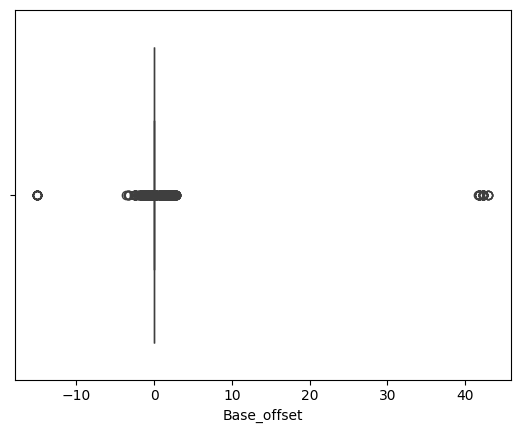

In [ ]:
sns.boxplot(x=df3['Base_offset'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Base_offset', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
12468,2347405,Ss_25_13_24,0.18,0.84,Non Load-Bearing,0.35,2.0,0.22,2.88,3.54,43.0,-0.7880999999999999,6,0.306756,2.406572,0.3967,18.136966608277657,29.550859807521345,44.193836796457916,1.2969534306764006,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12467,2347401,Ss_25_13_24,0.91,4.13,Non Load-Bearing,1.76,2.0,0.22,10.07,5.14,43.0,-0.7880999999999999,6,0.661215,2.367559,1.754963,18.408120044860365,28.53469240598514,44.175995596576804,1.3125779372271726,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12466,2347397,Ss_25_13_24,0.84,3.80,Non Load-Bearing,1.64,2.0,0.22,9.34,4.96,43.0,-0.7880999999999999,6,0.624889,2.336117,1.639402,18.838301876331272,26.893572067780674,44.160814305017,1.3164393799391727,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12465,2347393,Ss_25_13_24,0.73,3.32,Non Load-Bearing,1.45,2.0,0.22,8.28,4.76,43.0,-0.7880999999999999,6,0.558797,2.306244,1.457202,19.216700367235084,25.399307933870205,44.14672784181037,1.3300364413581218,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12472,2410055,Ss_25_13_24,0.42,1.91,Non Load-Bearing,0.86,2.0,0.22,5.18,3.96,42.3,-0.7880999999999999,6,0.321612,2.226983,0.883818,22.280751236409003,10.10346508264187,43.40817336262345,1.4508943722829029,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12461,2347377,Ss_25_13_24,0.79,3.59,Non Load-Bearing,1.48,2.0,0.22,8.89,4.89,42.3,-0.7880999999999999,6,0.567273,2.434624,1.490932,20.50795038387819,20.129492831088413,43.510150075035234,1.3298482217591245,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12453,2347345,Ss_25_13_24,1.43,6.50,Non Load-Bearing,3.46,2.0,0.22,15.35,6.64,42.3,-0.7880999999999999,6,0.533591,2.0,3.465621,23.718471667100502,-3.158592032271232,43.23980081605983,1.4797411203059865,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12454,2347349,Ss_25_13_24,1.15,5.22,Non Load-Bearing,2.65,2.0,0.22,12.47,5.83,42.3,-0.7880999999999999,6,0.503902,2.00178,2.662904,23.41913685431899,-0.1231640153827184,43.282576244922474,1.4632004137554964,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12456,2347357,Ss_25_13_24,0.68,3.07,Non Load-Bearing,1.40,2.0,0.22,7.73,4.58,42.3,-0.7880999999999999,6,0.385957,2.205703,1.416308,22.415994316115636,8.980698345233417,43.39731738851584,1.4508943722828997,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
12457,2347361,Ss_25_13_24,0.96,4.36,Non Load-Bearing,1.94,2.0,0.22,10.55,5.24,42.3,-0.7880999999999999,6,0.484794,2.265119,1.950457,22.09548964520555,11.493258149055714,43.4232734033139,1.4326865914534657,0,dataset7,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.19.5 Arredondar c/ 2 casas decimais

In [ ]:
df3["Base_offset"] = df3["Base_offset"].round(2)

## 2.20 Top_offset

### 2.20.1 Análise de valores

In [ ]:
df3['Top_offset'].value_counts()

Top_offset
None                    4559
0.0                     2921
-0.24999999999999997    1178
-0.29                   1125
-0.2                     535
                        ... 
-1.2000965417171165        1
1.29                       1
-0.53                      1
1.14                       1
0.8679087957864446         1
Name: count, Length: 248, dtype: int64

### 2.20.2 Replace None -> 0

In [ ]:
df3['Top_offset'] = df3['Top_offset'].replace('None', np.nan)
df3['Top_offset'].describe()

count     7791
unique     247
top        0.0
freq      2921
Name: Top_offset, dtype: object

In [ ]:
df3['Top_offset'] = df3['Top_offset'].replace(np.nan , 0)
df3['Top_offset'] = df3['Top_offset'].astype('float')
df3['Top_offset'].describe()

count    12350.000000
mean        -0.001686
std          0.535300
min         -4.700000
25%         -0.250000
50%          0.000000
75%          0.000000
max          3.550000
Name: Top_offset, dtype: float64

### 2.20.3 Análise valores = 0

In [ ]:
df3[df3['Top_offset'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
5,1309469,Ss_25_11_16_70,10.61,43.01,Load-Bearing,3.35,12.33,0.25,93.85,16.52,-0.35,0.0,10,3.554633,12.33,0.25,1103.9865996095232,282.1933242356232,83.89126686982645,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.20.4 Análise de outliers

<Axes: xlabel='Top_offset'>

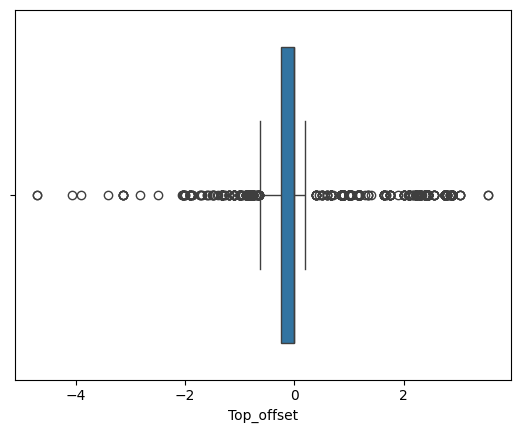

In [ ]:
sns.boxplot(x=df3['Top_offset'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Top_offset', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
11304,4388752,Ss_25_12,5.62,23.43,Non Load-Bearing,6.60,3.55,0.24,51.73,12.67,0.00,3.550000,6,6.603373,3.55,0.365692,-32.695015877077594,38.56524723538687,27.774998105377083,0.01905196494404704,0,dataset6,0,Ss_25,Ss_25_12,1,5,Walls,0,0,0,0,0,0,0,0,1,0,0
12430,2289397,Ss_25_30_20_30,0.00,6.67,Non Load-Bearing,9.96,0.67,0.00,33.90,0.00,2.88,3.545680,0,9.609358,0.67,4.658266,-2.4989185129143863,-2.615613652844979,46.51067964477531,0.3839724354387488,0,dataset7,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
668,1586224,Ss_20_30_75_15,0.18,1.53,Non Load-Bearing,2.57,0.00,0.00,3.05,3.97,0.00,3.040000,6,0.25,3.04,0.25,1053.00065625,289.3092339111328,94.60499750976562,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
976,1823927,Ss_20_30_75_15,0.17,1.45,Non Load-Bearing,2.57,0.00,0.00,2.90,3.85,0.15,3.040000,6,0.25,2.89,0.25,1053.00065625,295.2242310058594,94.67999758300782,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
669,1586226,Ss_20_30_75_15,0.18,1.53,Non Load-Bearing,2.57,0.00,0.00,3.05,4.03,0.00,3.040000,6,0.25,3.04,0.25,1056.500647265625,289.3092339111328,94.60499750976562,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
975,1823877,Ss_20_30_75_15,0.17,1.45,Non Load-Bearing,2.57,0.00,0.00,2.90,3.85,0.15,3.040000,6,0.25,2.89,0.25,1056.500647265625,295.2242310058594,94.67999758300782,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
10060,2061054,Ss_30_25,0.04,0.63,Non Load-Bearing,1.62,0.38,0.06,1.52,2.45,2.50,2.881514,6,1.653,0.381514,0.063,24.57575224914551,24.74041661682129,28.690756887817383,3.1415926535897905,0,dataset6,0,Ss_30,Ss_30_25,2,13,Walls,0,0,0,0,0,0,0,0,1,0,0
11542,5601835,Ss_30_25,0.04,0.63,Non Load-Bearing,1.62,0.38,0.06,1.52,2.40,2.50,2.881514,6,1.653,0.381514,0.063,39.57575178222656,24.806670712280276,28.690756887817383,3.1415926535897905,0,dataset6,0,Ss_30,Ss_30_25,2,13,Walls,0,0,0,0,0,0,0,0,1,0,0
11543,5601920,Ss_30_25,0.06,0.92,Non Load-Bearing,2.53,0.38,0.06,2.20,3.34,2.50,2.881514,6,0.063,0.381514,2.5265,38.78075263366699,23.565170910644532,28.690756887817383,1.5707963267948983,0,dataset6,0,Ss_30,Ss_30_25,2,13,Walls,0,0,0,0,0,0,0,0,1,0,0
10086,2065413,Ss_30_25,0.04,0.60,Non Load-Bearing,1.78,0.38,0.06,1.45,2.45,2.50,2.880000,6,1.776117,0.38,0.118277,15.899365567016602,27.590446142578127,35.28999942626953,0.03490658503993289,0,dataset6,0,Ss_30,Ss_30_25,2,13,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.20.5 Arredondar c/ duas casas decimais

In [ ]:
df3["Top_offset"] = df3["Top_offset"].round(2)

## 2.21 Number_of_Faces

### 2.21.1 Análise de valores

In [ ]:
df3['Number_of_Faces'].describe()

count     12350
unique       84
top           6
freq       6258
Name: Number_of_Faces, dtype: object

In [ ]:
df3['Number_of_Faces'].value_counts()

Number_of_Faces
6       6258
None    2618
8        628
9        568
12       411
        ... 
81         1
311        1
56         1
47         1
39         1
Name: count, Length: 84, dtype: int64

### 2.21.2 Análise valores None

In [ ]:
# Filtrar linhas onde Number_of_Faces é None
df_faces_none = df3[df3['Number_of_Faces'] == 'None']
df_faces_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_faces_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_30_20_25    Doors                     893
Ss_25_30_95       Windows                   447
Ss_25_30          Doors                     339
Ss_20_20_75_80    Structural Framing        288
Ss_20_20_75_85    Structural Framing        171
Ss_25_30          Windows                   123
Ss_20_30_75_80    Structural Columns        120
Ss_35_10_85_15    Stairs                     54
Ss_25_30_95       Curtain Panels             46
Ss_25_10_20       Curtain Panels             44
Ss_20_05_15_70    Structural Foundations     31
Ss_35_10          Stairs                     25
Ss_20_20_75_15    Structural Framing         19
Ss_20_05_15       Structural Foundations      6
Ss_25_30_20_30    Doors                       5
Ss_25_30_95       Doors                       3
Ss_40_15          Curtain Panels              2
Ss_20_30_75_15    Structural Columns          1
Ss_20_05_15       Structural Columns          1
Name: count, dtype: int64

### 2.21.3 Replace None -> 0

In [ ]:
df3['Number_of_Faces'] = df3['Number_of_Faces'].replace('None', 0)
df3['Number_of_Faces'] = df3['Number_of_Faces'].astype('float')
df3['Number_of_Faces'].describe()


count    12350.000000
mean         6.821538
std          8.837374
min          0.000000
25%          6.000000
50%          6.000000
75%          8.000000
max        333.000000
Name: Number_of_Faces, dtype: float64

### 2.21.4 Análise valores = 0

In [ ]:
df3[df3['Number_of_Faces'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.265828,2.385,1.212781,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.21.5 Análise de outliers

<Axes: xlabel='Number_of_Faces'>

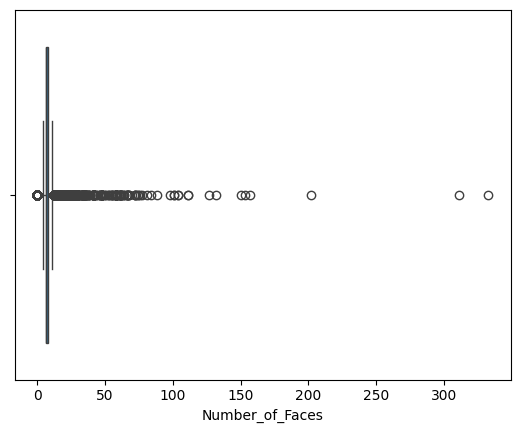

In [ ]:
sns.boxplot(x=df3['Number_of_Faces'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Number_of_Faces', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2623,1798832,Ss_20_05_15,24.34,0.00,Non Load-Bearing,1.00,0.00,0.00,180.11,161.06,0.00,0.00,333.0,43.140167,0.6,21.824702,991.4506372152257,319.52929056235763,86.25000052690908,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.00,0.35,3064.44,177.28,0.00,0.00,311.0,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
1363,1498890,Ss_20_30_75_15,11.32,58.28,Non Load-Bearing,63.51,0.00,0.00,116.56,89.04,0.00,0.00,202.0,63.512581,2.76,0.3,1012.4848334618385,282.83554440009425,95.60253211685226,4.910298507655744e-15,0,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
274,1515644,Ss_30_12_85_70,77.53,224.07,Load-Bearing,4.17,0.00,0.35,502.13,110.56,0.00,0.00,157.0,15.141141,0.35,17.309194,984.1461898339095,284.3623245857864,83.2344320430623,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
1803,1822340,Ss_20_20_75_15,6.29,39.57,Non Load-Bearing,50.14,0.00,0.00,79.13,69.51,0.00,0.00,153.0,50.142581,0.74,0.25,1019.11179865567,276.05385182862574,89.61942667232121,3.455321528157611e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1805,1822883,Ss_20_20_75_15,6.40,40.07,Non Load-Bearing,50.14,0.00,0.00,80.15,70.70,0.00,0.00,150.0,50.142581,0.75,0.25,1019.1340174224048,276.05386047824913,92.66442177324895,3.455321528157611e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
5699,8981891,Ss_25_13_50,58.17,146.42,Non Load-Bearing,5.65,28.76,0.40,327.85,67.02,-0.05,-0.29,132.0,5.649999999999998,28.760000000000012,0.40000000000000435,-115.73879853063741,68.12317784585453,101.54468862313162,3.141592653589793,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
11573,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.00,0.42,2321.99,254.75,0.00,0.00,127.0,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
1737,1711329,Ss_20_20_75_15,4.72,29.78,Non Load-Bearing,38.60,0.00,0.00,59.57,53.91,0.00,0.00,111.0,38.599935,0.74,0.25,1079.221319633361,295.24901623125015,83.52954018468434,2.6931455941242603e-15,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
336,1733522,Ss_30_12_05,129.87,519.34,Load-Bearing,4.17,0.00,0.25,1102.54,138.40,0.00,0.00,111.0,30.486522,0.25,19.182906,992.009847139154,313.72576661217397,86.67500247802735,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1


## 2.22 Bounding_Box_Width

### 2.22.1 Análise de valores

In [ ]:
df3['Bounding_Box_Width'].value_counts()

Bounding_Box_Width
0.15000000000000055    767
0.2                    291
0.3                    225
0.8000000000000087     224
0.3500000000000071     221
                      ... 
1.335                    1
1.5775                   1
1.335                    1
1.335                    1
1.213708                 1
Name: count, Length: 4023, dtype: int64

In [ ]:
df3['Bounding_Box_Width'].describe()

count                   12350
unique                   4023
top       0.15000000000000055
freq                      767
Name: Bounding_Box_Width, dtype: object

### 2.22.2 Análise valores None

In [ ]:
# Filtrar linhas onde Bounding_Box_Width é 0
df_bbw_none = df3[df3['Bounding_Box_Width'] == 'None']
df_bbw_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_bbw_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_30_95       Curtain Panels        2
Name: count, dtype: int64

### 2.22.3 Replace None -> 0

In [ ]:
df3['Bounding_Box_Width'] = df3['Bounding_Box_Width'].replace('None' , 0)
df3['Bounding_Box_Width'] = df3['Bounding_Box_Width'].astype('float')
df3['Bounding_Box_Width'].describe()

count    12350.000000
mean         2.573115
std          6.943114
min          0.000000
25%          0.300000
50%          0.797859
75%          2.126704
max        100.117097
Name: Bounding_Box_Width, dtype: float64

### 2.22.4 Análise valores = 0

In [ ]:
df3[df3['Bounding_Box_Width'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.22.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Width'>

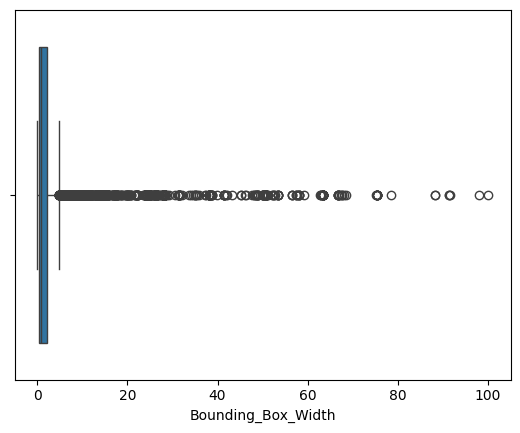

In [ ]:
sns.boxplot(x=df3['Bounding_Box_Width'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Width', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
11576,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.00,0.35,4491.06,176.58,0.00,0.00,32.0,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11575,1470420,Ss_30_12,835.73,879.72,Non Load-Bearing,1.63,0.00,0.95,1973.56,144.36,0.00,0.00,27.0,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11573,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.00,0.42,2321.99,254.75,0.00,0.00,127.0,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11583,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.00,0.42,2328.73,236.75,0.00,0.00,104.0,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11562,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.00,0.42,2340.00,234.70,0.00,0.00,98.0,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11590,3010068,Ss_30_12,341.34,568.90,Non Load-Bearing,1.63,0.00,0.60,1258.88,126.67,0.00,0.00,22.0,88.333146,0.6,19.65,8.717761294178983,15.02447466774426,22.400000170898437,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11561,334234,Ss_30_12,387.17,645.28,Non Load-Bearing,1.63,0.00,0.60,1431.99,145.74,0.00,0.00,24.0,88.172557,0.6,20.752183,14.565128313003745,15.133042228915217,25.699999905261187,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
11578,1916370,Ss_30_12,16.01,38.11,Non Load-Bearing,1.63,0.00,0.42,101.62,39.95,0.00,0.00,26.0,78.400341,0.42,3.853445,5.8677831927487185,25.494764191850436,29.089999960327148,None,None,dataset6,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.00,0.20,3528.96,159.08,0.00,0.00,42.0,75.430000,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2650,1542874,Ss_25_13_50,93.47,211.20,Non Load-Bearing,74.98,2.80,0.45,499.53,104.57,0.00,-0.20,18.0,75.430000,2.799999999999996,0.4500000000002442,-114.72356189152683,68.14976271611071,77.99999943237304,3.2350258330603172e-15,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.22.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Bounding_Box_Width"] = df3["Bounding_Box_Width"].round(2)

## 2.23 Bounding_Box_Height

### 2.23.1 Análise de valores

In [ ]:
df3['Bounding_Box_Height'].value_counts()

Bounding_Box_Height
2.1000000000000076    707
2.6500000000000212    698
2.660000000000002     663
2.88                  367
0.45                  334
                     ... 
3.126316                1
0.250017                1
2.93                    1
2.8279731934322765      1
3.035                   1
Name: count, Length: 940, dtype: int64

In [ ]:
df3['Bounding_Box_Height'].describe()

count                  12350
unique                   940
top       2.1000000000000076
freq                     707
Name: Bounding_Box_Height, dtype: object

### 2.23.2 Análise valores None

In [ ]:
# Filtrar linhas onde Bounding_Box_Height é 0
df_bbh_none = df3[df3['Bounding_Box_Height'] == 'None']
df_bbh_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_bbh_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_30_95       Curtain Panels        2
Name: count, dtype: int64

### 2.23.3 Replace None -> 0

In [ ]:
df3['Bounding_Box_Height'] = df3['Bounding_Box_Height'].replace('None' , 0)
df3['Bounding_Box_Height'] = df3['Bounding_Box_Height'].astype('float')
df3['Bounding_Box_Height'].describe()

count    12350.000000
mean         2.593251
std          2.675303
min          0.000000
25%          1.190000
50%          2.650000
75%          2.880000
max         32.700000
Name: Bounding_Box_Height, dtype: float64

### 2.23.4 Análise valores = 0

In [ ]:
df3[df3['Bounding_Box_Height'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.23.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Height'>

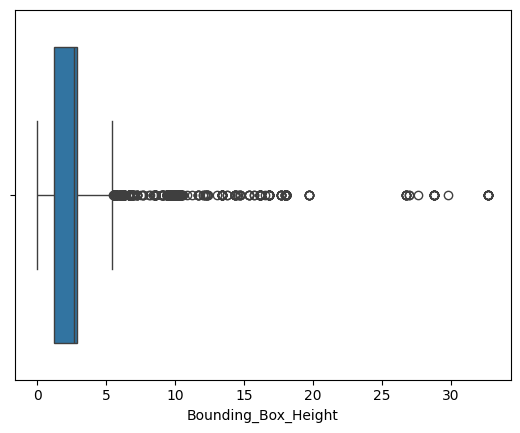

In [ ]:
sns.boxplot(x=df3['Bounding_Box_Height'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Height', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7671,1908333,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.15,13.911142158508301,21.815003320312503,99.34520119628907,1.570796326794819,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7673,1908337,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.149999,15.961142028808595,21.815003320312503,99.34520119628907,1.5707963267949017,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7679,1908353,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.149999,37.15311244812012,21.81500099487305,99.34520119628907,1.570796326794941,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7676,1908347,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.20,149.62,12.37,-0.30,-0.30,6.0,2.22,32.70,0.2,38.09061336364746,22.940000930786134,99.34520119628907,3.141592653589638,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7675,1908343,Ss_25_11_16_70,18.55,67.03,Load-Bearing,2.05,32.70,0.28,153.31,22.60,-0.30,-0.30,6.0,0.28,32.70,2.049999,33.61650622558594,21.814999832153323,99.34520119628907,1.5707963267948966,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7670,1908331,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.20,149.62,12.37,-0.30,-0.30,6.0,2.23,32.70,0.2,12.973641242980957,22.940003256225587,99.34520119628907,2.0791048882529185e-13,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7677,1908349,Ss_25_11_16_70,13.41,67.04,Load-Bearing,2.05,32.70,0.20,147.97,12.47,-0.30,-0.30,6.0,2.15,32.70,0.2,36.02811251220703,22.940000930786134,99.34520119628907,3.1415926535896688,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7674,1908341,Ss_25_11_16_70,25.80,93.20,Load-Bearing,3.10,32.70,0.28,206.07,11.70,-0.30,-0.30,6.0,0.28,32.70,3.099997,33.61650622558594,24.265000286865234,99.34520119628907,1.5707963267948883,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7678,1908351,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.15,35.103111996459965,21.81500099487305,99.34520119628907,1.5707963267949026,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
7672,1908335,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.05,32.70,0.20,147.97,12.47,-0.30,-0.30,6.0,2.15,32.70,0.2,15.036142094421388,22.940003256225587,99.34520119628907,1.605812718569185e-13,0,dataset3,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1


### 2.23.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Bounding_Box_Height"] = df3["Bounding_Box_Height"].round(2)

## 2.24 Bounding_Box_Depth

### 2.24.1 Análise de valores

In [ ]:
df3['Bounding_Box_Depth'].value_counts()

Bounding_Box_Depth
0.15000000000000055    464
0.2                    270
0.6096                 262
0.8500000000009417     195
0.073                  150
                      ... 
2.555418                 1
2.556721                 1
0.381276                 1
6.304131                 1
1.266203                 1
Name: count, Length: 4094, dtype: int64

In [ ]:
df3['Bounding_Box_Depth'].describe()

count                   12350
unique                   4094
top       0.15000000000000055
freq                      464
Name: Bounding_Box_Depth, dtype: object

### 2.24.2 Análise valores None

In [ ]:
# Filtrar linhas onde Bounding_Box_Depth é 0
df_bbd_none = df3[df3['Bounding_Box_Depth'] == 'None']
df_bbd_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_bbd_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_30_95       Curtain Panels        2
Name: count, dtype: int64

### 2.24.3 Replace None -> 0

In [ ]:
df3['Bounding_Box_Depth'] = df3['Bounding_Box_Depth'].replace('None' , 0)
df3['Bounding_Box_Depth'] = df3['Bounding_Box_Depth'].astype('float')
df3['Bounding_Box_Depth'].describe()

count    12350.000000
mean         1.766608
std          2.998528
min          0.000000
25%          0.205280
50%          0.800000
75%          1.870510
max         48.355298
Name: Bounding_Box_Depth, dtype: float64

### 2.24.4 Análise valores = 0

In [ ]:
df3[df3['Bounding_Box_Depth'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,dataset2,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.24.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Depth'>

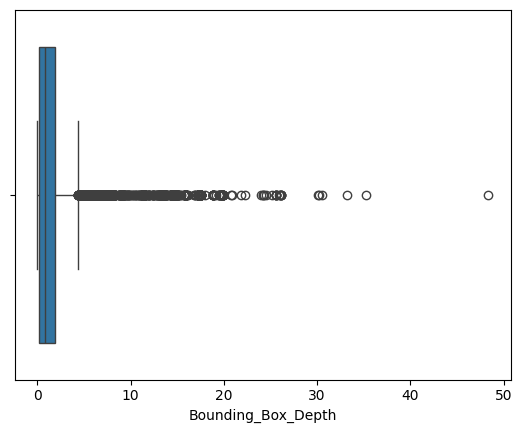

In [ ]:
sns.boxplot(x=df3['Bounding_Box_Depth'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Depth', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2622,1785701,Ss_20_05_15_70,64.35,0.00,Non Load-Bearing,1.00,0.00,0.00,405.23,201.01,0.00,0.00,42.0,50.54,3.89,48.355298,990.2560673600768,300.21750564441317,87.23290666202466,None,None,dataset1,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
9,1309491,Ss_25_11_16_70,17.34,69.35,Load-Bearing,35.26,3.45,0.25,158.32,46.65,-0.35,0.20,9.0,0.25,4.22,35.263573,1123.0006253906251,280.3715630672529,78.92305019131025,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.00,0.35,3064.44,177.28,0.00,0.00,311.0,53.40,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
11156,3839743,Ss_25_12,26.68,111.25,Non Load-Bearing,30.62,5.60,0.24,238.79,41.67,-1.00,0.00,6.0,3.33,5.60,30.488749,62.03285700142211,29.710589683108683,23.694435904250604,1.4695243586110005,0,dataset6,0,Ss_25,Ss_25_12,1,5,Walls,0,0,0,0,0,0,0,0,1,0,0
293,1590170,Ss_30_12_85_70,20.86,104.32,Load-Bearing,4.17,0.00,0.20,265.43,142.93,0.00,0.00,81.0,67.61,0.20,30.180195,1007.9544556221379,277.4418875987747,93.04000001220703,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
290,1574703,Ss_30_12_85_70,19.71,98.57,Load-Bearing,4.17,0.00,0.20,253.08,120.99,0.00,0.00,76.0,67.61,0.20,30.055195,1009.0816482669226,276.5836775486571,96.67000188351572,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
9326,699631,Ss_25_11,29.39,108.87,Non Load-Bearing,26.25,2.12,0.27,233.69,36.68,-0.72,-1.90,10.0,2.93,5.40,26.141495,58.32107661799994,23.83903368734445,22.512714399413873,1.6721474866980477,0,dataset6,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.00,0.20,3618.38,181.07,0.00,0.00,59.0,75.43,0.20,26.090000,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.00,0.20,3528.96,159.08,0.00,0.00,42.0,75.43,0.20,26.090000,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.97,Non Load-Bearing,2.05,0.00,0.20,3976.54,124.02,0.00,0.00,6.0,75.43,0.20,26.090000,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,dataset2,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


### 2.24.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Bounding_Box_Depth"] = df3["Bounding_Box_Depth"].round(2)

## 2.25 Centroid_X

### 2.25.1 Análise de valores

In [ ]:
df3['Centroid_X'].value_counts()

Centroid_X
None                   2618
0.2499999973654747       79
48.70500384521485        36
6.775000124359131        33
1056.500647265625        33
                       ... 
27.528105761718752        1
1049.5109180673494        1
1056.4776785446218        1
1102.001349214356         1
-10.409611151974142       1
Name: count, Length: 4979, dtype: int64

In [ ]:
df3['Centroid_X'].describe()

count     12350
unique     4979
top        None
freq       2618
Name: Centroid_X, dtype: object

### 2.25.2 Análise valores None

In [ ]:
# Filtrar linhas onde Centroid_X é 0
df_cx_none = df3[df3['Centroid_X'] == 'None']
df_cx_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_cx_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_30_20_25    Doors                     893
Ss_25_30_95       Windows                   447
Ss_25_30          Doors                     339
Ss_20_20_75_80    Structural Framing        288
Ss_20_20_75_85    Structural Framing        171
Ss_25_30          Windows                   123
Ss_20_30_75_80    Structural Columns        120
Ss_35_10_85_15    Stairs                     54
Ss_25_30_95       Curtain Panels             46
Ss_25_10_20       Curtain Panels             44
Ss_20_05_15_70    Structural Foundations     31
Ss_35_10          Stairs                     25
Ss_20_20_75_15    Structural Framing         19
Ss_20_05_15       Structural Foundations      6
Ss_25_30_20_30    Doors                       5
Ss_25_30_95       Doors                       3
Ss_40_15          Curtain Panels              2
Ss_20_30_75_15    Structural Columns          1
Ss_20_05_15       Structural Columns          1
Name: count, dtype: int64

### 2.25.3 Replace None -> 0

In [ ]:
df3['Centroid_X'] = df3['Centroid_X'].replace('None', 0)
df3['Centroid_X'] = df3['Centroid_X'].astype('float')
df3['Centroid_X'].describe()

count    12350.000000
mean       169.730848
std        429.186877
min       -151.930889
25%        -87.992731
50%          0.000000
75%         36.028113
max       1123.025629
Name: Centroid_X, dtype: float64

### 2.25.4 Análise valores = 0

In [ ]:
df3[df3['Centroid_X'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.25.5 Análise de outliers

<Axes: xlabel='Centroid_X'>

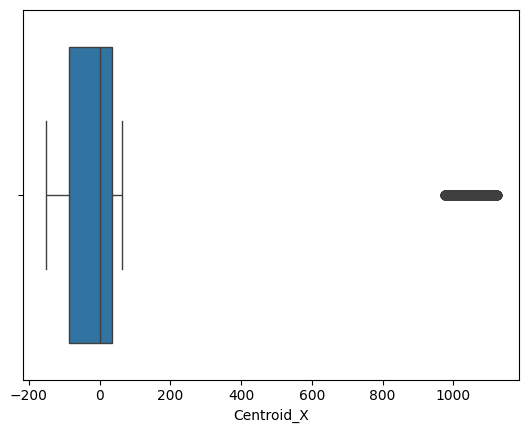

In [ ]:
sns.boxplot(x=df3['Centroid_X'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_X', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
37,1438933,Ss_25_11_16_70,3.12,15.58,Load-Bearing,13.03,1.20,0.20,36.82,12.46,-0.20,-2.00,6.0,0.20,1.20,13.13,1123.025629,288.5592052734375,81.40999826660156,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
493,1309463,Ss_20_30_75_15,0.10,0.75,Non Load-Bearing,4.17,0.00,0.00,1.49,0.90,-0.35,-0.20,8.0,0.25,3.05,0.40,1123.000625,295.14809180796533,80.29383654076558,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
498,1309477,Ss_20_30_75_15,0.10,0.76,Non Load-Bearing,4.17,0.00,0.00,1.51,1.58,-0.35,-0.20,6.0,0.25,3.05,0.40,1123.000625,282.2691892089844,80.30500059814453,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
51,1545381,Ss_25_11_16_70,0.30,1.20,Load-Bearing,1.58,0.83,0.25,3.54,2.50,-1.23,-3.40,6.0,0.25,0.83,1.58,1123.000625,297.4242362548828,80.1933469482422,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
1415,1545277,Ss_20_20_75_15,0.27,1.95,Non Load-Bearing,3.10,0.00,0.00,3.89,3.93,0.00,0.00,6.0,0.25,1.23,3.10,1123.000625,299.9492356201172,79.9549987060547,1.5707963267948966,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
501,1309489,Ss_20_30_75_15,0.11,0.87,Non Load-Bearing,4.17,0.00,0.00,1.73,2.15,-0.35,0.00,6.0,0.20,3.25,0.55,1123.000625,289.46923344726565,80.30500059814453,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
644,1546059,Ss_20_30_75_15,0.16,1.38,Non Load-Bearing,2.57,0.00,0.00,2.75,2.95,-1.23,-1.60,6.0,0.25,2.63,0.25,1123.000625,298.2742401855469,81.09499888916017,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
9,1309491,Ss_25_11_16_70,17.34,69.35,Load-Bearing,35.26,3.45,0.25,158.32,46.65,-0.35,0.20,9.0,0.25,4.22,35.26,1123.000625,280.3715630672529,78.92305019131025,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
645,1546732,Ss_20_30_75_15,0.16,1.38,Non Load-Bearing,2.57,0.00,0.00,2.75,2.78,-1.23,-1.60,6.0,0.25,2.63,0.25,1123.000625,301.6242310546875,81.09499888916017,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
50,1544710,Ss_25_11_16_70,0.11,0.54,Load-Bearing,0.27,1.10,0.25,1.72,0.92,-1.23,-3.13,6.0,0.25,1.10,0.49,1122.992828,301.96000032291244,80.32999907226564,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1


### 2.25.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Centroid_X"] = df3["Centroid_X"].round(2)

## 2.26 Centroid Y

### 2.26.1 Análise de valores

In [ ]:
df3['Centroid_Y'].describe()

count     12350
unique     4643
top        None
freq       2618
Name: Centroid_Y, dtype: object

In [ ]:
df3['Centroid_Y'].value_counts()

Centroid_Y
None                  2618
11.339999098205567      84
18.489999879455567      70
60.7739253112793        70
287.6592322998047       54
                      ... 
67.59272537841797        1
63.653926263427735       1
62.97047808260924        1
61.54798020407463        1
-4.752080421453377       1
Name: count, Length: 4643, dtype: int64

### 2.26.2 Análise valores None

In [ ]:
# Filtrar linhas onde Centroid_Y é None
df_cy_none = df3[df3['Centroid_Y'] == 'None']
df_cy_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_cy_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_30_20_25    Doors                     893
Ss_25_30_95       Windows                   447
Ss_25_30          Doors                     339
Ss_20_20_75_80    Structural Framing        288
Ss_20_20_75_85    Structural Framing        171
Ss_25_30          Windows                   123
Ss_20_30_75_80    Structural Columns        120
Ss_35_10_85_15    Stairs                     54
Ss_25_30_95       Curtain Panels             46
Ss_25_10_20       Curtain Panels             44
Ss_20_05_15_70    Structural Foundations     31
Ss_35_10          Stairs                     25
Ss_20_20_75_15    Structural Framing         19
Ss_20_05_15       Structural Foundations      6
Ss_25_30_20_30    Doors                       5
Ss_25_30_95       Doors                       3
Ss_40_15          Curtain Panels              2
Ss_20_30_75_15    Structural Columns          1
Ss_20_05_15       Structural Columns          1
Name: count, dtype: int64

### 2.26.3 Replace None -> 0

In [ ]:
df3['Centroid_Y'] = df3['Centroid_Y'].replace('None', 0)
df3['Centroid_Y'] = df3['Centroid_Y'].astype('float')
df3['Centroid_Y'].describe()

count    12350.000000
mean        78.727457
std        104.143129
min        -38.969816
25%          0.973133
50%         29.807920
75%         65.467526
max        323.135774
Name: Centroid_Y, dtype: float64

### 2.26.4 Análise valores = 0

In [ ]:
df3[df3['Centroid_Y'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.26.5 Análise outliers

<Axes: xlabel='Centroid_Y'>

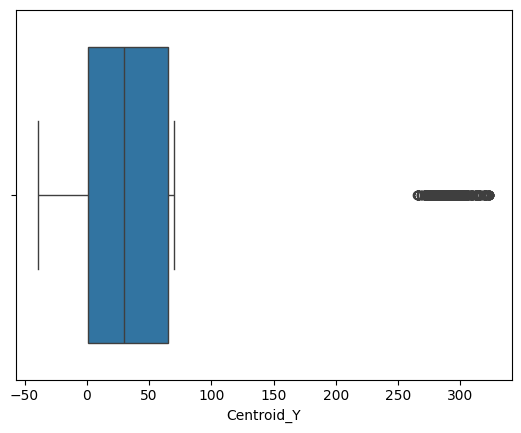

In [ ]:
sns.boxplot(x=df3['Centroid_Y'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_Y', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
179,2059774,Ss_20_05_15_70,0.97,1.50,Load-Bearing,1.20,1.25,0.65,6.18,3.57,-0.25,-2.06,6.0,1.20,1.25,0.65,1015.42,323.135774,87.40499978027344,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
176,2058977,Ss_20_05_15_70,1.76,3.28,Load-Bearing,1.20,2.73,0.65,11.13,6.91,-0.23,-0.56,10.0,1.20,2.73,0.65,992.62,323.099728,88.22592157755984,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
175,2058836,Ss_20_05_15_70,1.68,3.16,Load-Bearing,1.20,2.63,0.65,10.76,6.87,-0.23,-0.66,10.0,1.20,2.63,0.65,987.82,323.098062,88.16794138498871,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
174,2058403,Ss_20_05_15_70,1.68,3.16,Load-Bearing,1.20,2.63,0.65,10.76,5.66,-0.23,-0.66,10.0,1.20,2.63,0.65,983.02,323.098062,88.16794143963587,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
177,2059172,Ss_20_05_15_70,1.51,2.86,Load-Bearing,1.20,2.38,0.65,9.87,6.49,-0.28,-0.96,10.0,1.20,2.38,0.65,999.82,323.096259,87.98152059401802,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
178,2059538,Ss_20_05_15_70,1.22,2.33,Load-Bearing,1.24,1.88,0.65,8.33,4.93,-0.28,-1.46,10.0,1.24,1.88,0.65,1007.04,323.094145,87.72400625410924,0.0,0,dataset1,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,1
2467,2286848,Ss_20_20_75_15,0.42,3.23,Non Load-Bearing,2.80,0.00,0.00,6.46,7.04,0.00,0.00,11.0,2.80,1.03,0.30,1003.72,322.848815,89.56209435865927,0.0,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1801,1779369,Ss_25_11_16_70,2.33,8.84,Non Load-Bearing,1.80,0.00,0.00,17.68,5.31,0.00,0.00,10.0,0.35,4.39,1.80,987.65,322.122934,87.72909823369585,1.5707963267948966,0,dataset1,0,Ss_25,Ss_25_11,1,4,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2453,2255014,Ss_20_20_75_15,1.51,7.39,Non Load-Bearing,7.18,0.00,0.00,14.78,7.63,0.00,0.00,6.0,7.18,0.70,0.30,1003.72,321.460769,86.9000026977539,0.0,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2470,2286932,Ss_20_20_75_15,0.37,2.90,Non Load-Bearing,3.10,0.00,0.00,5.80,6.40,0.00,0.00,12.0,0.30,1.03,3.10,1002.47,321.448807,89.51899508027307,1.5707963267948966,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0


### 2.26.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Centroid_Y"] = df3["Centroid_Y"].round(2)

## 2.27 Centroid Z

### 2.27.1 Análise de valores

In [ ]:
df3['Centroid_Z'].describe()

count     12350
unique     3471
top        None
freq       2618
Name: Centroid_Z, dtype: object

In [ ]:
df3['Centroid_Z'].value_counts()

Centroid_Z
None                  2618
30.740000408935547     280
34.04000014343262      241
27.439999511718753     141
27.34999919128418      110
                      ... 
85.28198741290116        1
85.24280846462749        1
85.52379217285886        1
85.38420869956046        1
47.093327304790115       1
Name: count, Length: 3471, dtype: int64

### 2.27.2 Análise valores None

In [ ]:
# Filtrar linhas onde Centroid_Z é None
df_cz_none = df3[df3['Centroid_Z'] == 'None']
df_cz_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_cz_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_30_20_25    Doors                     893
Ss_25_30_95       Windows                   447
Ss_25_30          Doors                     339
Ss_20_20_75_80    Structural Framing        288
Ss_20_20_75_85    Structural Framing        171
Ss_25_30          Windows                   123
Ss_20_30_75_80    Structural Columns        120
Ss_35_10_85_15    Stairs                     54
Ss_25_30_95       Curtain Panels             46
Ss_25_10_20       Curtain Panels             44
Ss_20_05_15_70    Structural Foundations     31
Ss_35_10          Stairs                     25
Ss_20_20_75_15    Structural Framing         19
Ss_20_05_15       Structural Foundations      6
Ss_25_30_20_30    Doors                       5
Ss_25_30_95       Doors                       3
Ss_40_15          Curtain Panels              2
Ss_20_30_75_15    Structural Columns          1
Ss_20_05_15       Structural Columns          1
Name: count, dtype: int64

### 2.27.3 Replace None -> 0

In [ ]:
df3['Centroid_Z'] = df3['Centroid_Z'].replace('None', 0)
df3['Centroid_Z'] = df3['Centroid_Z'].astype('float')
df3['Centroid_Z'].describe()

count    12350.000000
mean        59.970850
std         41.392888
min         -4.101148
25%         24.350000
50%         81.375000
75%         96.220453
max        116.979999
Name: Centroid_Z, dtype: float64

### 2.27.4 Análise valores = 0

In [ ]:
df3[df3['Centroid_Z'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,dataset1,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.27.5 Análise de outliers

<Axes: xlabel='Centroid_Z'>

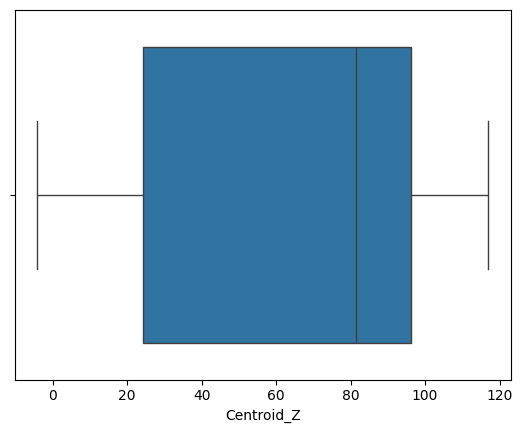

In [ ]:
sns.boxplot(x=df3['Centroid_Z'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_Z', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5597,8662090,Ss_37_17_13_50,0.12,0.79,Non Load-Bearing,0.60,1.76,0.15,2.25,1.62,0.0,-0.25,6.0,0.15,1.76,0.60,-102.86,63.17,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5575,8660794,Ss_37_17_13_50,0.16,1.06,Non Load-Bearing,0.60,1.76,0.15,2.83,1.81,0.0,-0.25,6.0,0.68,1.76,0.15,-140.63,63.11,116.979999,0.0,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5769,9779545,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-119.09,64.19,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5770,9779547,Ss_37_17_13_50,0.15,0.97,Non Load-Bearing,0.40,1.76,0.15,2.63,1.74,0.0,-0.25,6.0,0.55,1.76,0.15,-112.57,65.21,116.979999,0.0,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5771,9779548,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-112.37,64.19,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5772,9779549,Ss_37_17_13_50,0.15,0.97,Non Load-Bearing,0.40,1.76,0.15,2.63,1.74,0.0,-0.25,6.0,0.55,1.76,0.15,-112.57,63.16,116.979999,3.141592653589793,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5773,9779550,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-112.77,64.19,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5763,9779522,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-128.07,64.19,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5564,8658375,Ss_37_17_13_50,0.13,0.88,Non Load-Bearing,0.35,1.76,0.15,2.44,1.68,0.0,-0.25,6.0,0.50,1.76,0.15,-151.61,64.23,116.979999,0.0,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5565,8658449,Ss_37_17_13_50,0.53,3.53,Non Load-Bearing,2.00,1.76,0.15,8.18,3.52,0.0,-0.25,6.0,0.15,1.76,2.08,-151.44,63.15,116.979999,1.5707963267948966,0,dataset2,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.27.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Centroid_Z"] = df3["Centroid_Z"].round(2)

## 2.28 Orientation_Angle

### 2.28.1 Análise de valores

In [ ]:
df3['Orientation_Angle'].describe()

count     12350
unique     1947
top        None
freq       4047
Name: Orientation_Angle, dtype: object

In [ ]:
df3['Orientation_Angle'].value_counts()

Orientation_Angle
None                      4047
1.5707963267948966        2709
0.0                       1126
3.141592653589793          505
3.14159265358979           111
                          ... 
2.4063713984412295e-14       1
2.4063713984412873e-14       1
2.4610616574963655e-14       1
2.5782550697584558e-14       1
2.757620333991223            1
Name: count, Length: 1947, dtype: int64

### 2.28.2 Análise valores None

In [ ]:
# Filtrar linhas onde Orientation_Angle é None
df_oa_none = df3[df3['Orientation_Angle'] == 'None']
df_oa_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.00,0.35,771.94,45.40,0.0,0.0,55.0,27.75,0.35,13.36,1030.09,282.84,83.83,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.00,0.20,704.40,29.30,0.0,0.0,20.0,28.00,0.20,13.36,1030.98,282.60,86.93,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.00,0.20,718.09,74.84,0.0,0.0,37.0,27.95,0.20,13.61,1030.67,282.64,89.99,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.00,0.20,657.02,32.91,0.0,0.0,15.0,23.79,0.20,13.59,1004.10,282.82,86.93,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.00,0.20,398.20,21.14,0.0,0.0,6.0,12.97,0.20,14.92,987.46,282.26,89.99,None,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_oa_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_20_30_75_15    Structural Columns        1375
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_30_12_85_18    Floors                     145
Ss_20_30_75_80    Structural Columns         127
Ss_25_30          Windows                    123
Ss_20_05_15_70    Structural Foundations     117
Ss_30_12_85_70    Floors                     102
Ss_35_10_85_15    Stairs                      54
Ss_30_12_05       Floors                      48
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15       Structural Foundations      35
Ss_30_12          Floors                      34
Ss_35_10          Stairs                      25
Ss_20_05_15       Structural Columns          19
Ss_25_50_35       Floors                      19
Ss_35_10_85_15    Floors                      18
Ss_30_12_85_18    Roofs     

### 2.28.3 Replace None -> 0

In [ ]:
df3['Orientation_Angle'] = df3['Orientation_Angle'].replace('None', 0)
df3['Orientation_Angle'] = df3['Orientation_Angle'].astype('float')
df3['Orientation_Angle'].describe()

count    12350.000000
mean         0.917233
std          1.089732
min          0.000000
25%          0.000000
50%          0.021102
75%          1.570796
max          3.141593
Name: Orientation_Angle, dtype: float64

### 2.28.4 Análise valores = 0

In [ ]:
df3[df3['Orientation_Angle'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5,1309469,Ss_25_11_16_70,10.61,43.01,Load-Bearing,3.35,12.33,0.25,93.85,16.52,-0.35,0.0,10.0,3.55,12.33,0.25,1103.99,282.19,83.89,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
13,1309504,Ss_25_11_16_70,13.13,43.76,Load-Bearing,13.56,3.25,0.30,97.55,14.35,-0.35,0.0,6.0,13.56,3.25,0.30,1109.14,295.20,79.39,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
14,1309506,Ss_25_11_16_70,5.30,21.20,Load-Bearing,5.82,3.25,0.25,47.11,11.76,-0.35,0.0,6.0,5.82,3.72,0.25,1120.03,296.57,79.62,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
26,1309843,Ss_25_11_16_70,7.63,25.42,Load-Bearing,7.15,3.75,0.30,57.57,11.57,-0.35,0.5,9.0,7.25,4.22,0.30,1119.17,295.20,79.97,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
27,1309869,Ss_25_11_16_70,8.85,35.39,Load-Bearing,3.61,10.81,0.25,81.10,24.03,-1.73,0.0,10.0,3.61,10.21,0.25,1104.01,277.96,84.38,0.0,0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.28.5 Análise de outliers

<Axes: xlabel='Orientation_Angle'>

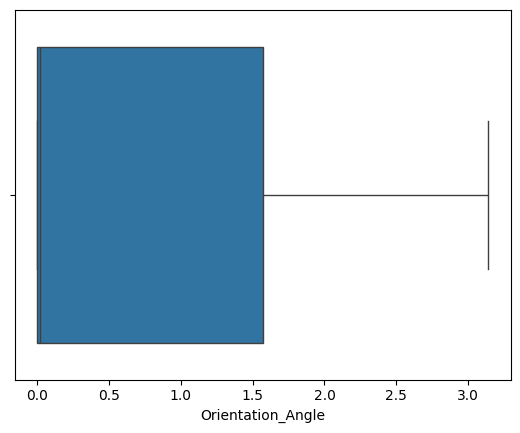

In [ ]:
sns.boxplot(x=df3['Orientation_Angle'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Orientation_Angle', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
3082,4574814,Ss_25_10_30_35,1.20,7.98,Non Load-Bearing,3.00,2.66,0.15,17.66,5.97,-0.05,-0.29,6.0,3.17,2.66,0.15,-85.11,60.67,102.88,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
4283,5812537,Ss_25_10_30_35,1.73,11.52,Non Load-Bearing,4.35,2.65,0.15,25.15,7.54,0.00,-0.25,6.0,4.42,2.65,0.15,-149.33,62.30,88.43,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
3210,4635741,Ss_25_10_30_35,1.10,8.39,Non Load-Bearing,4.19,2.65,0.15,23.42,12.10,0.00,-0.25,11.0,4.19,2.65,0.15,-144.47,64.55,91.45,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
3211,4635762,Ss_25_10_30_35,1.73,11.52,Non Load-Bearing,4.35,2.65,0.15,25.15,7.54,0.00,-0.25,6.0,4.42,2.65,0.15,-149.33,62.30,91.33,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
2028,2044154,Ss_20_20_75_15,0.12,0.99,Non Load-Bearing,1.74,0.00,0.00,1.97,2.05,0.00,0.00,6.0,1.74,0.42,0.20,1097.62,290.14,86.81,3.141593,0,dataset1,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
4906,7750923,Ss_25_10_30_35,1.15,7.70,Non Load-Bearing,2.35,3.50,0.15,17.11,7.04,0.00,-0.20,6.0,2.35,3.50,0.15,-121.98,60.80,85.15,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
2988,4514456,Ss_25_13_50,2.92,8.35,Non Load-Bearing,3.50,2.65,0.35,20.75,5.90,0.00,-0.25,6.0,3.50,2.65,0.35,-113.73,60.77,91.33,3.141593,0,dataset2,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
4286,5812554,Ss_25_10_30_35,0.57,3.79,Non Load-Bearing,1.58,2.65,0.15,8.80,4.24,0.00,-0.25,6.0,1.58,2.65,0.15,-147.87,63.95,88.43,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
4285,5812550,Ss_25_10_30_35,0.72,4.77,Non Load-Bearing,2.05,2.65,0.15,10.87,4.53,0.00,-0.25,6.0,2.05,2.65,0.15,-133.60,64.50,88.43,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
2991,4514532,Ss_25_10_30_35,0.85,5.70,Non Load-Bearing,2.25,2.65,0.15,12.83,5.04,0.00,-0.25,6.0,2.33,2.65,0.15,-113.23,58.10,91.33,3.141593,0,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.28.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Orientation_Angle"] = df3["Orientation_Angle"].round(2)

## 2.29 Curvature

### 2.29.1 Análise de valores

In [ ]:
df3['Curvature'].describe()

count     12350
unique       11
top           0
freq       8272
Name: Curvature, dtype: object

In [ ]:
df3['Curvature'].value_counts()

Curvature
0                      8272
None                   4047
0.39843137254901967      12
0.4800000000000001        6
2.0157006623252687        5
0.09098507462686573       2
0.8350684931506851        2
0.07949709762306124       1
0.09222390317700453       1
1.966532826209713         1
0.0633106701079233        1
Name: count, dtype: int64

### 2.29.2 Análise valores None

In [ ]:
# Filtrar linhas onde Curvature é None
df_c_none = df3[df3['Curvature'] == 'None']
df_c_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.00,0.35,771.94,45.40,0.0,0.0,55.0,27.75,0.35,13.36,1030.09,282.84,83.83,0.0,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.00,0.20,704.40,29.30,0.0,0.0,20.0,28.00,0.20,13.36,1030.98,282.60,86.93,0.0,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.00,0.20,718.09,74.84,0.0,0.0,37.0,27.95,0.20,13.61,1030.67,282.64,89.99,0.0,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.00,0.20,657.02,32.91,0.0,0.0,15.0,23.79,0.20,13.59,1004.10,282.82,86.93,0.0,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.00,0.20,398.20,21.14,0.0,0.0,6.0,12.97,0.20,14.92,987.46,282.26,89.99,0.0,None,dataset1,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_c_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_20_30_75_15    Structural Columns        1375
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_30_12_85_18    Floors                     145
Ss_20_30_75_80    Structural Columns         127
Ss_25_30          Windows                    123
Ss_20_05_15_70    Structural Foundations     117
Ss_30_12_85_70    Floors                     102
Ss_35_10_85_15    Stairs                      54
Ss_30_12_05       Floors                      48
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15       Structural Foundations      35
Ss_30_12          Floors                      34
Ss_35_10          Stairs                      25
Ss_20_05_15       Structural Columns          19
Ss_25_50_35       Floors                      19
Ss_35_10_85_15    Floors                      18
Ss_30_12_85_18    Roofs     

### 2.29.3 Replace None -> 0

In [ ]:
df3['Curvature'] = df3['Curvature'].replace('None', 0)
df3['Curvature'] = df3['Curvature'].astype('float')
df3['Curvature'].describe()

count    12350.000000
mean         0.001765
std          0.048344
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.015701
Name: Curvature, dtype: float64

### 2.29.4 Análise valores = 0

In [ ]:
df3[df3['Curvature'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,Ss_25_11_16_70,11.05,44.21,Load-Bearing,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12858,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12859,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12860,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
12861,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,dataset7,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.29.5 Análise de outliers

<Axes: xlabel='Curvature'>

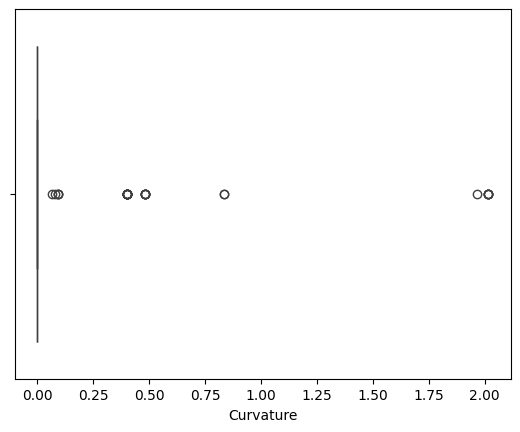

In [ ]:
sns.boxplot(x=df3['Curvature'])

In [ ]:
# Ordenar pelas maiores
df3.sort_values(by='Curvature', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5505,8419291,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.5,0.00,0.25,0.60,2.40,0.00,6.0,0.15,0.5,0.16,-105.08,61.70,112.95,0.82,2.015701,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5520,8419475,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.5,0.00,0.24,0.59,2.40,0.00,6.0,0.15,0.5,0.15,-129.46,61.92,112.95,0.79,2.015701,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5504,8418991,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.5,0.00,0.24,0.59,2.40,0.00,6.0,0.15,0.5,0.15,-126.62,61.13,112.95,0.79,2.015701,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5514,8419468,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.5,0.00,0.24,0.59,2.40,0.00,6.0,0.15,0.5,0.15,-150.42,61.14,112.95,0.78,2.015701,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5513,8419467,Ss_25_10_30_35,0.00,0.11,Non Load-Bearing,0.22,0.5,0.00,0.23,0.58,2.40,0.00,6.0,0.14,0.5,0.15,-101.19,61.69,112.95,2.32,2.015701,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5524,8419599,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.24,0.5,0.00,0.25,0.60,2.40,0.00,6.0,0.16,0.5,0.16,-78.35,61.14,112.95,0.78,1.966533,dataset2,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
10003,1791366,Ss_25_13,0.30,2.70,Non Load-Bearing,1.15,2.0,0.13,5.40,1.40,0.00,-0.62,6.0,0.86,2.0,0.43,48.00,24.91,37.05,3.14,0.835068,dataset6,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
10004,1791367,Ss_25_13,0.30,2.70,Non Load-Bearing,1.15,2.0,0.13,5.40,1.40,0.00,-0.62,6.0,0.86,2.0,0.43,48.00,24.45,37.05,0.00,0.835068,dataset6,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
11234,4091126,Ss_25_13,0.26,2.20,Non Load-Bearing,1.99,1.0,0.13,4.77,2.43,0.00,-0.62,6.0,1.40,1.0,0.70,28.67,24.19,36.55,0.00,0.480000,dataset6,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
11226,4090934,Ss_25_13,0.26,2.20,Non Load-Bearing,1.99,1.0,0.13,4.77,2.43,0.00,-0.62,6.0,1.40,1.0,0.70,-1.57,24.19,36.55,0.00,0.480000,dataset6,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.29.6 Arredondar c/ 2 casas decimais

In [ ]:
df3["Curvature"] = df3["Curvature"].round(2)

## 2.30 Apagar colunas que já não interessam

In [ ]:
df4 = df3.copy()

In [ ]:
df4.columns

Index(['ElementID', 'SECClasS_Code_Ss', 'Volume', 'Area',
       'load_bearing_status', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_original',
       'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
       'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

In [ ]:
datasetpisos = df4.copy()

df4 = df4.drop(['SECClasS_Code_Ss', 'load_bearing_status',
              'Category_original'
], axis=1)

df4.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
1,1306674,5.35,26.76,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
2,1306676,4.72,23.58,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
3,1306762,4.60,18.42,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
4,1306764,3.57,14.47,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1


# 3. Matriz Correlação

In [ ]:
df4.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_Curtain Panels',
       'Category_Doors', 'Category_Floors', 'Category_Roofs',
       'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

## 3.1. Matriz de correlação - Piso Ordinal

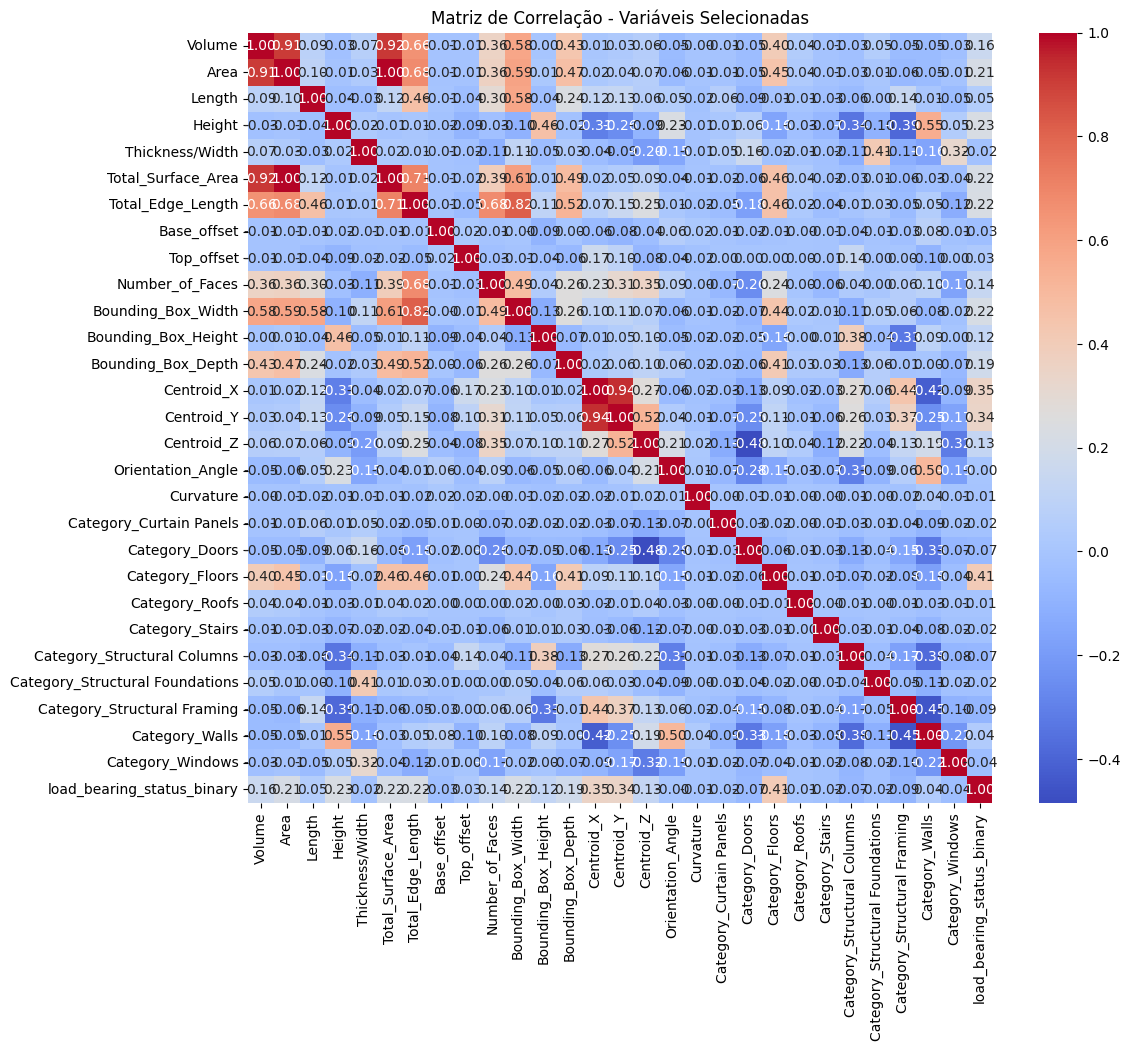

In [ ]:
# Lista das variáveis que deseja incluir na matriz de correlação
selected_columns = [
    'Volume', 'Area', 
    'Length', 'Height', 'Thickness/Width',
    'Total_Surface_Area', 'Total_Edge_Length', 
    'Base_offset','Top_offset', 'Number_of_Faces', 
    'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth', 
    'Centroid_X', 'Centroid_Y', 'Centroid_Z', 
    'Orientation_Angle', 'Curvature',
    'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
    'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
    'Category_Structural Foundations', 'Category_Structural Framing',
    'Category_Walls', 'Category_Windows', 
    'load_bearing_status_binary'
]

# Criar um subconjunto do DataFrame apenas com essas variáveis
subset_data = df4[selected_columns]

# Gerar a matriz de correlação
correlation_matrix = subset_data.corr()

# Plotar a matriz de correlação como um heatmap
plt.figure(figsize=(12, 10))  # Ajuste o tamanho conforme necessário
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis Selecionadas")
plt.show()

In [ ]:
high_corr_pairs = correlation_matrix.where(
    (correlation_matrix.abs() > 0.7)
)

high_corr_pairs.head(40)

,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
Volume,1.000000,0.909739,NaN,NaN,NaN,0.918650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,0.909739,1.000000,NaN,NaN,NaN,0.997188,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thickness/Width,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Surface_Area,0.918650,0.997188,NaN,NaN,NaN,1.000000,0.708828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Edge_Length,NaN,NaN,NaN,NaN,NaN,0.708828,1.000000,NaN,NaN,NaN,0.8168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_offset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top_offset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_of_Faces,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


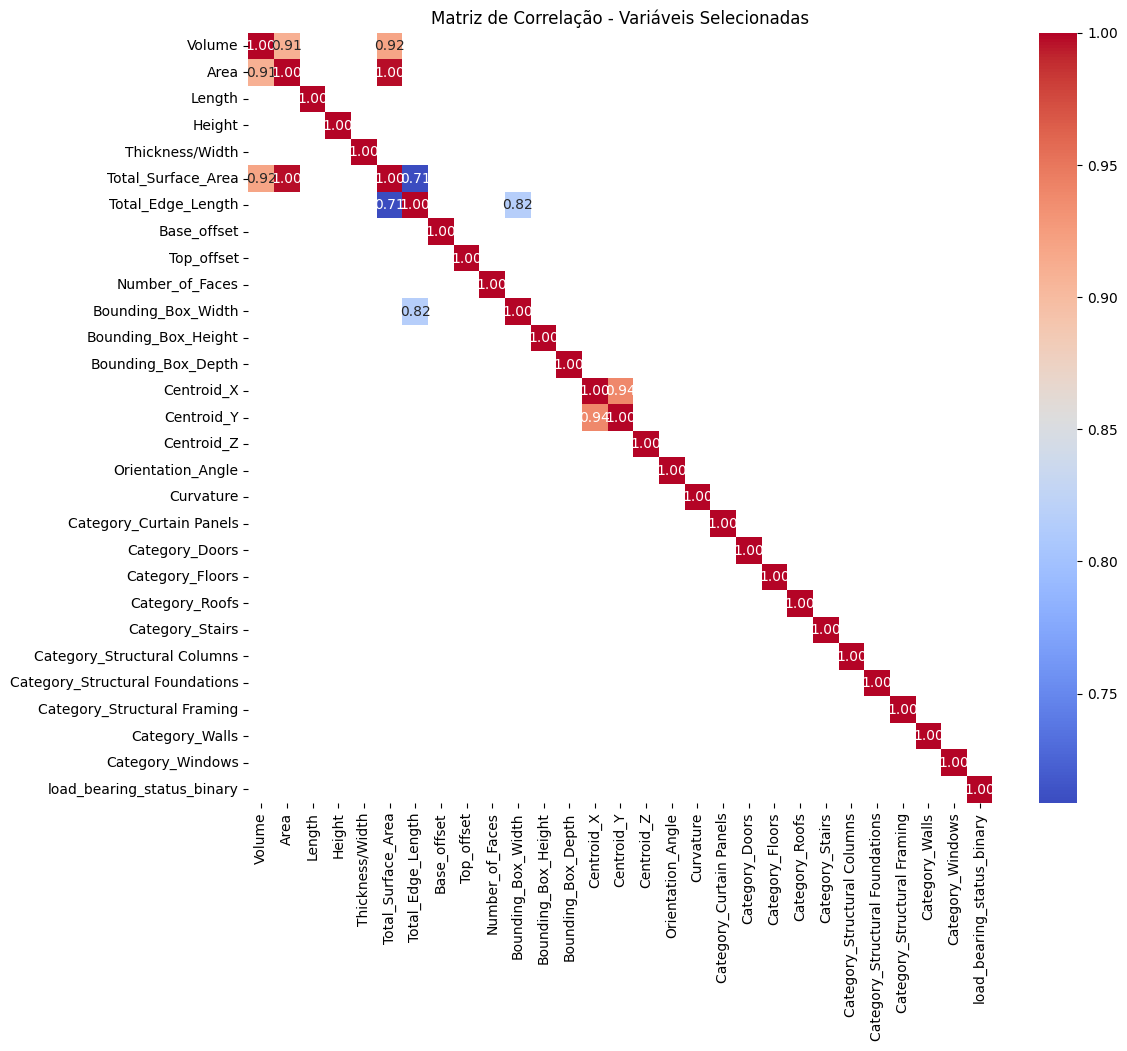

In [ ]:
# Plotar a matriz de correlação como um heatmap
plt.figure(figsize=(12, 10))  # Ajuste o tamanho conforme necessário
sns.heatmap(high_corr_pairs, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis Selecionadas")
plt.show()

## 3.3 Eliminar variáveis muito correlacionadas

Total_Surface_Area, Total_Edge_Length

In [ ]:
df4.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_Curtain Panels',
       'Category_Doors', 'Category_Floors', 'Category_Roofs',
       'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

In [ ]:
df5 = df4.copy()

In [ ]:
df5 = df5.drop([ 'Total_Surface_Area', 'Total_Edge_Length'], axis=1)

df5.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
1,1306674,5.35,26.76,27.20,1.00,0.20,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
2,1306676,4.72,23.58,23.59,1.00,0.20,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
3,1306762,4.60,18.42,5.74,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1
4,1306764,3.57,14.47,4.40,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,dataset1,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,1


## 3.4 Testar novamente as correlações

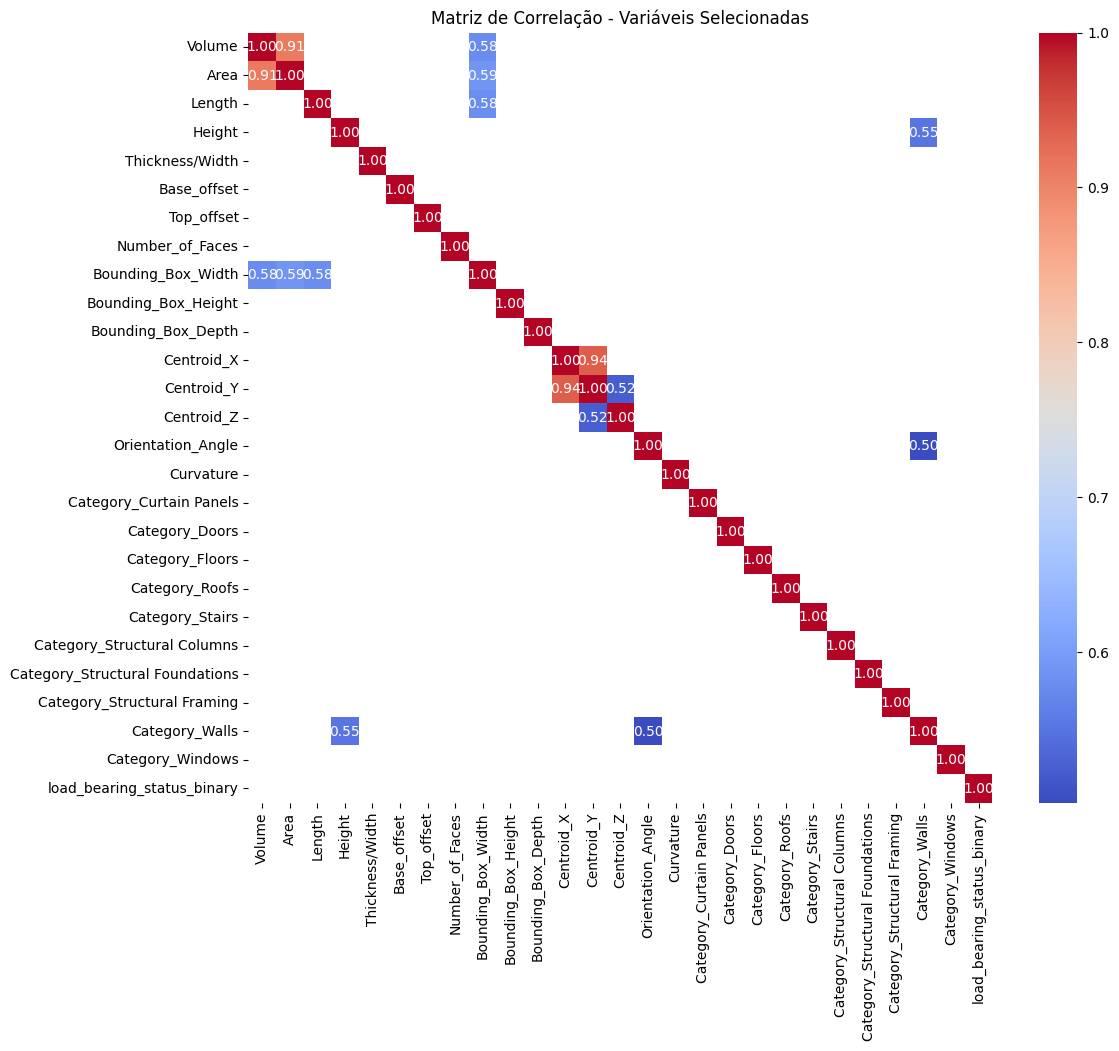

In [ ]:
# Lista das variáveis que deseja incluir na matriz de correlação
selected_columns2 = [
    'Volume', 'Area', 
    'Length', 'Height', 'Thickness/Width',
    'Base_offset','Top_offset', 'Number_of_Faces', 
    'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth', 
    'Centroid_X', 'Centroid_Y', 'Centroid_Z', 
    'Orientation_Angle', 'Curvature',
    'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
    'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
    'Category_Structural Foundations', 'Category_Structural Framing',
    'Category_Walls', 'Category_Windows', 
    'load_bearing_status_binary'
]

# Criar um subconjunto do DataFrame apenas com essas variáveis
subset_data2 = df5[selected_columns2]

# Gerar a matriz de correlação
correlation_matrix2 = subset_data2.corr()

high_corr_pairs2 = correlation_matrix2.where(
    (correlation_matrix2.abs() > 0.5)
)

# Plotar a matriz de correlação como um heatmap
plt.figure(figsize=(12, 10))  # Ajuste o tamanho conforme necessário
sns.heatmap(high_corr_pairs2, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis Selecionadas")
plt.show()

In [ ]:
data = df5.copy()

# 4. Dividir por Datasets

## 4.1. 1º Nível Target

In [ ]:
data4_1 = data.copy()

In [ ]:
data4_1 = data4_1.drop(['SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_2_encode'], axis=1)

data4_1.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_1_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,dataset1,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,1
1,1306674,5.35,26.76,27.20,1.00,0.20,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,dataset1,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,1
2,1306676,4.72,23.58,23.59,1.00,0.20,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,dataset1,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,1
3,1306762,4.60,18.42,5.74,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,dataset1,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,1
4,1306764,3.57,14.47,4.40,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,dataset1,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,1


In [ ]:
data4_1.to_csv(r"C:\Users\HUAWEI\OneDrive\Ambiente de Trabalho\Tese\Final\data4_1.csv", index=False)

In [ ]:
data4_1.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Base_offset', 'Top_offset', 'Number_of_Faces', 'Bounding_Box_Width',
       'Bounding_Box_Height', 'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y',
       'Centroid_Z', 'Orientation_Angle', 'Curvature', 'source',
       'is_rare_class', 'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode',
       'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
       'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

## 4.2. 2º Nível Target

In [ ]:
data4_2 = data.copy()

In [ ]:
data4_2 = data4_2.drop(['SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode'], axis=1)

data4_2.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_2,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,dataset1,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,1
1,1306674,5.35,26.76,27.20,1.00,0.20,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,dataset1,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,1
2,1306676,4.72,23.58,23.59,1.00,0.20,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,dataset1,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,1
3,1306762,4.60,18.42,5.74,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,dataset1,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,1
4,1306764,3.57,14.47,4.40,3.37,0.25,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,dataset1,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,1


In [ ]:
data4_2.to_csv(r"C:\Users\HUAWEI\OneDrive\Ambiente de Trabalho\Tese\Final\data4_2.csv", index=False)

# 3. Preparação do `DATASET.csv` (à parte)

Nesta secção aplicamos um pipeline semelhante ao usado para gerar `data4_1.csv`/`data4_2.csv`, mas agora a partir do `DATASET.csv` (export do Revit com `;`), gerando dois ficheiros finais:

- `DATASET_Ss_1_prepared.csv`
- `DATASET_Ss_2_prepared.csv`

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1) Ler o DATASET.csv ---
# Nota: separador ';'
df_ds_raw = pd.read_csv('DATASET.csv', sep=';', engine='python')

# Compatibilidade com versões antigas do export (quando existia uma 1ª coluna "modelo"/separador)
first_col = str(df_ds_raw.columns[0]).strip() if len(df_ds_raw.columns) else ''
first_col_l = first_col.lower()
if first_col.startswith('4PH-') or first_col_l == 'modelos' or first_col_l.startswith('unnamed') or first_col == '':
    df_ds_raw = df_ds_raw.drop(columns=[df_ds_raw.columns[0]])

# Renomear colunas para nomes mais simples
col_map = {
    '[I] Family and Type': 'Family_and_Type',
    '[I] Type': 'Type',
    '[I] Workset': 'Workset',
    '[I] Category': 'Category',
    '[I] IfcGUID': 'IfcGUID',
    '[I] Level': 'Level',
    '[I] Mark': 'Mark',
    '[T] Type IfcGUID': 'Type_IfcGUID',
    '[T] Workset': 'Type_Workset',
    '[T] Family Name': 'Family_Name',
    '[I] Construction Block': 'Construction_Block',
    '[T] Classification Number': 'Classification_Number',
    '[T] Type Name': 'Type_Name',
    '[T] Category': 'Type_Category',
    '[I] Type Id': 'Type_Id',
    '[I] Volume': 'Volume_raw',
    'Target (EF_CODE)': 'Target_EF_CODE',
    'Target (Ss_CODE)': 'Target_Ss_CODE',
    'Target (Pr_CODE)': 'Target_Pr_CODE',
}

df_ds = df_ds_raw.rename(columns=col_map).copy()

# --- 2) Feature engineering m�nimo (Volume + alguns IDs) ---
# Volume: remover unidades, lidar com ',' como separador decimal
vol = df_ds['Volume_raw'].astype('string')
vol = vol.str.replace(',', '.', regex=False)
vol = vol.str.replace(r'[^0-9.\-]+', '', regex=True)
df_ds['Volume'] = pd.to_numeric(vol, errors='coerce').fillna(0.0)

# Type_Id para int (quando poss�vel)
df_ds['Type_Id'] = pd.to_numeric(df_ds['Type_Id'], errors='coerce').fillna(-1).astype(int)

# Colunas de compatibilidade (mesmos nomes do pipeline anterior)
df_ds['ElementID'] = df_ds['IfcGUID'].astype('string')
df_ds['source'] = 'DATASET'

# Target principal (equivalente ao SECClasS S)
df_ds['SECClasS_Code_Ss'] = df_ds['Target_Ss_CODE'].astype('string')

# --- 3) Remover classes raras (mesma regra do notebook) ---
freq = df_ds['SECClasS_Code_Ss'].value_counts()
n_min = 30
rare_classes = freq[freq < n_min].index

df_ds['is_rare_class'] = df_ds['SECClasS_Code_Ss'].isin(rare_classes).astype(int)
df_ds = df_ds[df_ds['is_rare_class'] != 1].copy()

# --- 4) Criar duas granularidades do c�digo (como SECClasS_Code_Ss_1 e _2) ---
df_ds['SECClasS_Code_Ss_1'] = df_ds['SECClasS_Code_Ss'].str.slice(0, 5)
df_ds['SECClasS_Code_Ss_2'] = df_ds['SECClasS_Code_Ss'].str.slice(0, 8)

encoder1 = LabelEncoder()
encoder2 = LabelEncoder()

df_ds['SECClasS_Code_Ss_1_encode'] = encoder1.fit_transform(df_ds['SECClasS_Code_Ss_1'])
df_ds['SECClasS_Code_Ss_2_encode'] = encoder2.fit_transform(df_ds['SECClasS_Code_Ss_2'])

# --- 5) One-hot encoding de algumas vari�veis categ�ricas ---
# (mantemos o pipeline simples e controlamos a dimensionalidade)
cat_cols = [c for c in ['Category', 'Workset', 'Level', 'Construction_Block'] if c in df_ds.columns]
df_ds_ohe = pd.get_dummies(df_ds, columns=cat_cols, prefix=cat_cols)

# Sele��o de colunas finais
base_cols = [
    'ElementID',
    'Volume',
    'Type_Id',
    'source',
    'is_rare_class',
    'SECClasS_Code_Ss',
    'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode',
    'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_2_encode',
]

ohe_prefixes = tuple(f'{c}_' for c in cat_cols)
ohe_cols = sorted([c for c in df_ds_ohe.columns if c.startswith(ohe_prefixes)])

prepared = df_ds_ohe[base_cols + ohe_cols].copy()

# --- 6) Construir 2 vers�es finais (an�logas a data4_1 e data4_2) ---
DATASET_Ss_1 = prepared.drop(['SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_2_encode'], axis=1)
DATASET_Ss_2 = prepared.drop(['SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode'], axis=1)

# Exportar para a pasta do projeto (caminhos relativos)
df_ds_raw.to_csv('DATASET_Ss_1_prepared.csv', sep=';', index=False)
df_ds_raw.to_csv('DATASET_Ss_2_prepared.csv', sep=';', index=False)

print('DATASET_Ss_1_prepared.csv ->', DATASET_Ss_1.shape)
print('DATASET_Ss_2_prepared.csv ->', DATASET_Ss_2.shape)
print('n_features (Ss_1):', len([c for c in DATASET_Ss_1.columns if c not in ['ElementID','source','is_rare_class','SECClasS_Code_Ss_1','SECClasS_Code_Ss_1_encode','SECClasS_Code_Ss']]))
print('n_features (Ss_2):', len([c for c in DATASET_Ss_2.columns if c not in ['ElementID','source','is_rare_class','SECClasS_Code_Ss_2','SECClasS_Code_Ss_2_encode','SECClasS_Code_Ss']]))


DATASET_Ss_1_prepared.csv -> (80525, 95)
DATASET_Ss_2_prepared.csv -> (80525, 95)
n_features (Ss_1): 89
n_features (Ss_2): 89
